In [2]:
# package imported
import requests
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime, timedelta
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten

import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten
from keras.optimizers import Adam



from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
import scipy.stats as stats
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
import json

In [ ]:
# load data
def load_and_process_sr_data(start_date, end_date):
    # col names
    column_names = ['Date+T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10',
                    'T11', 'T12', 'T13', 'T14', 'T15', 'F1', 'F2', 'F3', 'SR', 'A', 'Circ pump counter']

    dataframes = {}
    current_date = start_date

    while current_date <= end_date:
        file_name = f'data_{current_date.strftime("%Y-%m-%d")}.csv'
        date_key = current_date.strftime("%Y-%m-%d")

        try:
            # load the data
            data = pd.read_csv(file_name, header=None, names=column_names)

            # handle 'Date+T1' if concatenated
            if '-' in data.iloc[0, 0]:
                new_cols = data['Date+T1'].str.split(' T1:', expand=True)
                data['Date'] = new_cols[0]
                data['T1'] = new_cols[1].astype(float)
            else:
                data = data.reset_index().rename(columns={'index': 'Date'})

            # Clean and select necessary columns
            data['SR'] = data['SR'].str.split(':').str[1].astype(float)
            data = data[['Date', 'SR']].dropna()

            # Store the DataFrame in the dictionary with the date as the key
            dataframes[date_key] = data

        except FileNotFoundError:
            print(f"File not found: {file_name}")
        except Exception as e:
            print(f"Error reading {file_name}: {e}")

        current_date += timedelta(days=1)

    # Concatenate all DataFrames
    recent_data = pd.concat(dataframes.values())
    recent_data['Date'] = pd.to_datetime(recent_data['Date'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
    recent_data['Dates'] = recent_data['Date'].dt.date
    recent_data['Time'] = recent_data['Date'].dt.time
    recent_data = recent_data[['Dates', 'Time', 'SR']].dropna().sort_values(by=['Dates'])
    return recent_data

start_date = datetime(2024, 5, 21)

In [ ]:
# weekend change
url_start_date = "2024-08-08"
url_end_date = "2024-08-11"

uvindex_adjustment = 0

# Weather data API
yst_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/yesterday?unitGroup=metric&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"
last_7_day_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/last7days?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
last_15_day_url =  "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/last15days?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
tmr_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/tomorrow?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
next_7_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/next7days?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
next_30_day_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/next30days?unitGroup=metric&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"
next_24_hours_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/next24hours?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
today_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/today?include=fcst%2Cobs%2Chistfcst%2Cstats%2Cdays%2Chours&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"


self_define_url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/{url_start_date}/{url_end_date}?unitGroup=metric&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"



In [ ]:
# tmr weather function
def get_tmr_weather_df():
    # URL setup for tomorrow's weather data
    tmr_date = datetime.now() + timedelta(days=1)
    tmr_response = requests.get(tmr_url)

    # Check if the request was successful
    if tmr_response.status_code == 200:
        # Parse the JSON data
        weather_data = tmr_response.json()
        print("Data retrieved successfully!")

        # File path setup for saving the data
        tmr_file_path = f"{tmr_date.strftime('%Y-%m-%d')}_weather_data.json"
        with open(tmr_file_path, 'w') as f:
            json.dump(weather_data, f, indent=4)
        print("Weather data saved successfully!")

        # Load and parse the JSON data into a DataFrame
        with open(tmr_file_path, 'r') as file:
            tmr_json_data = json.load(file)

        # Initialize an empty list to hold all hourly data
        tmr_hourly_data = []

        # Loop through each day in the data
        for day in tmr_json_data['days']:
            # Extract each 'hour' from 'hours' array and enrich it with 'day' level data
            for hour in day['hours']:
                hour.update({
                    'date': day['datetime'],
                    'tempmax': day['tempmax'],
                    'tempmin': day['tempmin'],
                    'feelslikemax': day['feelslikemax'],
                    'feelslikemin': day['feelslikemin'],
                    'sunrise': day['sunrise'],
                    'sunset': day['sunset'],
                    'moonphase': day['moonphase'],
                    'conditions': day['conditions'],
                    'description': day['description'],
                    'icon': day['icon']
                })
                tmr_hourly_data.append(hour)

        # Create a DataFrame from the hourly data
        tmr_hourly_df = pd.DataFrame(tmr_hourly_data)

        # Define the columns of interest
        columns_of_interest = [
            'date', 'datetime', 'temp', 'tempmax', 'tempmin', 'feelslike', 'feelslikemax', 'feelslikemin',
            'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth',
            'windgust', 'windspeed', 'winddir', 'pressure', 'cloudcover', 'visibility',
            'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset',
            'moonphase', 'conditions', 'description', 'icon'
        ]


        # Reindex and rename the DataFrame
        tmr_hourly_df = tmr_hourly_df.reindex(columns=columns_of_interest).rename(columns={"date": "Dates", "datetime": "Time"})
        latitude = 49.2827

        def get_declination(day_of_year):
            return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

        def get_hour_angle(time, longitude):
            total_hours = time.hour + time.minute / 60 + time.second / 3600
            solar_noon = 12 - (longitude / 15)
            return 15 * (total_hours - solar_noon)

        def solar_elevation(latitude, declination, hour_angle):
            latitude_rad = np.deg2rad(latitude)
            declination_rad = np.deg2rad(declination)
            hour_angle_rad = np.deg2rad(hour_angle)
            elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                                    np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
            return np.rad2deg(elevation_rad)

        tmr_hourly_df['Time'] = pd.to_datetime(tmr_hourly_df['Time'])
        tmr_hourly_df['Sun Angle'] = tmr_hourly_df['Time'].apply(
            lambda x: solar_elevation(
                latitude,
                get_declination(x.timetuple().tm_yday),
                get_hour_angle(x, longitude=-123.1207)
            )
        )
        return tmr_hourly_df
    else:
        print("Failed to retrieve data:", tmr_response.status_code)
        return None


# function to store weather prediction
def store_and_update_weather_prediction(tmr_weather_df):

    # Current date for the existing file and next day for the new file name
    current_date = datetime.now().strftime('%Y-%m-%d')
    next_date = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')

    # File paths
    existing_file_name = f'weather_prediction_till_{current_date}.csv'
    new_file_name = f'weather_prediction_till_{next_date}.csv'

    # Check if the current file exists
    if os.path.exists(existing_file_name):
        # Read the existing CSV file
        existing_data = pd.read_csv(existing_file_name)
        # Concatenate the new data
        updated_data = pd.concat([existing_data, tmr_weather_df], ignore_index=True)
        print("Existing data found and updated.")
    else:
        # If the file does not exist, just use the new data
        updated_data = tmr_weather_df
        print(f"No existing file found for today ({current_date}). A new file will be created.")

    # Save the updated data to the new file name
    updated_data.to_csv(new_file_name, index=False)

    # Delete the old file if it exists
    if os.path.exists(existing_file_name):
        os.remove(existing_file_name)
        print(f"Old file '{existing_file_name}' deleted successfully.")

    # Confirm the new file creation
    if os.path.exists(new_file_name):
        print(f"New file '{new_file_name}' created successfully with updated predictions.")
    else:
        print(f"Failed to create the new file '{new_file_name}'.")



# function to store weather prediction -- Overweekend version
def over_weekend_store_and_update_weather_prediction(tmr_weather_df):

    # Current date for the existing file and next day for the new file name
    current_date = (datetime.now() - timedelta(days=2)).strftime('%Y-%m-%d')
    next_date = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')

    # File paths
    existing_file_name = f'weather_prediction_till_{current_date}.csv'
    new_file_name = f'weather_prediction_till_{next_date}.csv'

    # Check if the current file exists
    if os.path.exists(existing_file_name):
        # Read the existing CSV file
        existing_data = pd.read_csv(existing_file_name)
        # Concatenate the new data
        updated_data = pd.concat([existing_data, tmr_weather_df], ignore_index=True)
        print("Existing data found and updated.")
    else:
        # If the file does not exist, just use the new data
        updated_data = tmr_weather_df
        print(f"No existing file found for today ({current_date}). A new file will be created.")

    # Save the updated data to the new file name
    updated_data.to_csv(new_file_name, index=False)

    # Delete the old file if it exists
    if os.path.exists(existing_file_name):
        os.remove(existing_file_name)
        print(f"Old file '{existing_file_name}' deleted successfully.")

    # Confirm the new file creation
    if os.path.exists(new_file_name):
        print(f"New file '{new_file_name}' created successfully with updated predictions.")
    else:
        print(f"Failed to create the new file '{new_file_name}'.")



# revised_tmr_weather
def revise_tmr(tmr_hourly_df):
      tmr_hourly_df['hour'] = pd.to_datetime(tmr_hourly_df['Time'], format='%H:%M:%S').dt.hour
      tmr_hourly_df.loc[tmr_hourly_df['hour'] >= 18, 'uvindex'] = 0
      tmr_hourly_df.loc[(tmr_hourly_df['hour'] > 13) & (tmr_hourly_df['hour'] < 18) & (tmr_hourly_df['uvindex'] > 5), 'uvindex'] -= uvindex_adjustment
      tmr_hourly_df = tmr_hourly_df.drop(columns=['hour'])
      return tmr_hourly_df


def get_today_weather_df():
    # URL setup for tomorrow's weather data
    today_date = datetime.now()
    today_response = requests.get(today_url)

    # Check if the request was successful
    if today_response.status_code == 200:
        # Parse the JSON data
        weather_data = today_response.json()
        print("Data retrieved successfully!")

        # File path setup for saving the data
        today_file_path = f"{today_date.strftime('%Y-%m-%d')}_weather_data.json"
        with open(today_file_path, 'w') as f:
            json.dump(weather_data, f, indent=4)
        print("Weather data saved successfully!")

        # Load and parse the JSON data into a DataFrame
        with open(today_file_path, 'r') as file:
            today_json_data = json.load(file)

        # Initialize an empty list to hold all hourly data
        today_hourly_data = []

        # Loop through each day in the data
        for day in today_json_data['days']:
            # Extract each 'hour' from 'hours' array and enrich it with 'day' level data
            for hour in day['hours']:
                hour.update({
                    'date': day['datetime'],
                    'tempmax': day['tempmax'],
                    'tempmin': day['tempmin'],
                    'feelslikemax': day['feelslikemax'],
                    'feelslikemin': day['feelslikemin'],
                    'sunrise': day['sunrise'],
                    'sunset': day['sunset'],
                    'moonphase': day['moonphase'],
                    'conditions': day['conditions'],
                    'description': day['description'],
                    'icon': day['icon']
                })
                today_hourly_data.append(hour)

        # Create a DataFrame from the hourly data
        today_hourly_df = pd.DataFrame(today_hourly_data)

        # Define the columns of interest
        columns_of_interest = [
            'date', 'datetime', 'temp', 'tempmax', 'tempmin', 'feelslike', 'feelslikemax', 'feelslikemin',
            'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth',
            'windgust', 'windspeed', 'winddir', 'pressure', 'cloudcover', 'visibility',
            'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset',
            'moonphase', 'conditions', 'description', 'icon'
        ]


        # Reindex and rename the DataFrame
        today_hourly_df = today_hourly_df.reindex(columns=columns_of_interest).rename(columns={"date": "Dates", "datetime": "Time"})
        latitude = 49.2827

        def get_declination(day_of_year):
            return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

        def get_hour_angle(time, longitude):
            total_hours = time.hour + time.minute / 60 + time.second / 3600
            solar_noon = 12 - (longitude / 15)
            return 15 * (total_hours - solar_noon)

        def solar_elevation(latitude, declination, hour_angle):
            latitude_rad = np.deg2rad(latitude)
            declination_rad = np.deg2rad(declination)
            hour_angle_rad = np.deg2rad(hour_angle)
            elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                                    np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
            return np.rad2deg(elevation_rad)

        today_hourly_df['Time'] = pd.to_datetime(today_hourly_df['Time'])
        today_hourly_df['Sun Angle'] = today_hourly_df['Time'].apply(
            lambda x: solar_elevation(
                latitude,
                get_declination(x.timetuple().tm_yday),
                get_hour_angle(x, longitude=-123.1207)
            )
        )
        today_hourly_df['hour'] = pd.to_datetime(today_hourly_df['Time'], format='%H:%M:%S').dt.hour
        today_hourly_df.loc[today_hourly_df['hour'] >= 18, 'uvindex'] = 0
        today_hourly_df.loc[(today_hourly_df['hour'] > 13) & (today_hourly_df['hour'] < 18) & (today_hourly_df['uvindex'] > 5), 'uvindex'] -= uvindex_adjustment
        today_hourly_df = today_hourly_df.drop(columns=['hour'])

        return today_hourly_df
    else:
        print("Failed to retrieve data:", today_response.status_code)
        return None


    # function to store yesterday's weather json

yst_date = datetime.now() - timedelta(days=3)
yst_response = requests.get(yst_url)

# Check if the request was successful
if yst_response.status_code == 200:
    # Parse the JSON data
    weather_data = yst_response.json()
    print("Data retrieved successfully!")

    # File path setup for saving the data
    yst_file_path = f"{yst_date.strftime('%Y-%m-%d')}_weather_data.json"
    with open(yst_file_path, 'w') as f:
        json.dump(weather_data, f, indent=4)
    print("Weather data saved successfully!")



# update the total weather dataframe: append yst day data and delete the pervious
def update_weather_data(previous_csv_path, json_data_path):
    # Load the existing CSV data if available
    if os.path.exists(previous_csv_path):
        weather_df = pd.read_csv(previous_csv_path)
        # Ensure 'Dates' is in the correct datetime format
        weather_df['Dates'] = pd.to_datetime(weather_df['Dates'], errors='coerce')
        # Drop any rows where 'Dates' could not be converted
        weather_df.dropna(subset=['Dates'], inplace=True)
    else:
        print("No previous data file found, starting new dataset.")
        weather_df = pd.DataFrame()

    with open(yst_file_path, 'r') as file:
        json_data = json.load(file)

    # Prepare new data from JSON to match the DataFrame structure
    new_rows = []
    for day in json_data['days']:
        for hour in day['hours']:
            hour.update({
                'Dates': day['datetime'],
                'Time': hour['datetime'],
                # Include other necessary columns here
                'tempmax': day['tempmax'],
                'tempmin': day['tempmin'],
                'feelslikemax': day['feelslikemax'],
                'feelslikemin': day['feelslikemin'],
                'sunrise': day['sunrise'],
                'sunset': day['sunset'],
                'moonphase': day['moonphase'],
                'conditions': day['conditions'],
                'description': day['description'],
                'icon': day['icon']
            })
            new_rows.append(hour)

    # Convert to DataFrame, handle 'Dates' and 'Time' formatting
    new_df = pd.DataFrame(new_rows)
    new_df['Dates'] = pd.to_datetime(new_df['Dates'], errors='coerce')
    new_df['Time'] = pd.to_datetime(new_df['Time'], format='%H:%M:%S').dt.time
    new_df = new_df[['Dates', 'Time', 'temp', 'feelslike', 'dew', 'humidity', 'precip',
        'precipprob', 'preciptype', 'snow', 'snowdepth', 'windgust',
        'windspeed', 'winddir', 'cloudcover', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'conditions']]

    # Combine with existing data
    combined_df = pd.concat([weather_df, new_df], ignore_index=True)

    # Check for empty DataFrame
    if combined_df.empty:
        print("No data available to process.")
        return

    # Define new filename based on the date range
    start_date = combined_df['Dates'].min().strftime('%Y%m%d')
    end_date = combined_df['Dates'].max().strftime('%Y%m%d')
    new_filename = f"weather_{start_date}_to_{end_date}.csv"
    new_file_path = f'{new_filename}'

    # Save the combined data to a new file
    combined_df.to_csv(new_file_path, index=False)

    # Optionally delete the old CSV file if it's different from the new file
    if previous_csv_path != new_file_path and os.path.exists(previous_csv_path):
        os.remove(previous_csv_path)
        print(f"Deleted old data file: {previous_csv_path}")

    print(f"Data combined and saved successfully as {new_filename}")




# overweekend data storage
self_define_response = requests.get(self_define_url)

# Check if the request was successful
if self_define_response.status_code == 200:
    # Parse the JSON data
    weather_data = self_define_response.json()
    print("Data retrieved successfully!")

    # File path setup for saving the data
    self_define_file_path = f"{url_start_date}_{url_end_date}_weather_data.json"
    with open(self_define_file_path, 'w') as f:
        json.dump(weather_data, f, indent=4)
    print("Weather data saved successfully!")



def over_weekend_update_weather_data(previous_csv_path, json_data_path):
    # Load the existing CSV data if available
    if os.path.exists(previous_csv_path):
        weather_df = pd.read_csv(previous_csv_path)
        weather_df['Dates'] = pd.to_datetime(weather_df['Dates'], errors='coerce')
        weather_df.dropna(subset=['Dates'], inplace=True)
    else:
        print("No previous data file found, starting new dataset.")
        weather_df = pd.DataFrame()

    with open(json_data_path, 'r') as file:
        json_data = json.load(file)

    new_rows = []
    for day in json_data['days']:
        for hour in day['hours']:
            hour_data = {
                'Dates': day['datetime'],
                'Time': hour['datetime'],
                'temp': hour['temp'],
                'feelslike': hour['feelslike'],
                'dew': hour['dew'],
                'humidity': hour['humidity'],
                'precip': hour['precip'],
                'precipprob': hour['precipprob'],
                'preciptype': hour.get('preciptype'),
                'snow': hour['snow'],
                'snowdepth': hour['snowdepth'],
                'windgust': hour['windgust'],
                'windspeed': hour['windspeed'],
                'winddir': hour['winddir'],
                'pressure': hour['pressure'],
                'cloudcover': hour['cloudcover'],
                'solarradiation': hour['solarradiation'],
                'solarenergy': hour['solarenergy'],
                'uvindex': hour['uvindex'],
                'severerisk': hour['severerisk'],
                'conditions': hour['conditions'],
                'icon': hour['icon']
            }
            new_rows.append(hour_data)


    new_df = pd.DataFrame(new_rows)
    new_df['Dates'] = pd.to_datetime(new_df['Dates'], errors='coerce')
    new_df['Time'] = pd.to_datetime(new_df['Time'], format='%H:%M:%S').dt.time

    combined_df = pd.concat([weather_df, new_df], ignore_index=True)

    if combined_df.empty:
        print("No data available to process.")
        return

    start_date = combined_df['Dates'].min().strftime('%Y%m%d')
    end_date = combined_df['Dates'].max().strftime('%Y%m%d')
    new_filename = f"weather_{start_date}_to_{end_date}.csv"
    new_file_path = f'{new_filename}'

    combined_df.to_csv(new_file_path, index=False)
    if previous_csv_path != new_file_path and os.path.exists(previous_csv_path):
        os.remove(previous_csv_path)
        print(f"Deleted old data file: {previous_csv_path}")

    print(f"Data combined and saved successfully as {new_filename}")


# get raw combined data, add sun angle, day/night, hourly SR
def preprocess_and_merge(all_SR, all_wea):
    # Convert Dates and Time to appropriate datetime formats
    all_SR['Dates'] = pd.to_datetime(all_SR['Dates'])
    all_SR['Time'] = pd.to_datetime(all_SR['Time'], format='%H:%M:%S').dt.time

    # Define average sunrise and sunset times for Vancouver by month
    sun_times = {
        'Jun': ('05:06', '21:10'),
        'May': ('05:12', '20:30'),
        'Apr': ('05:51', '19:45'),
        'Mar': ('06:37', '17:57'),
        'Feb': ('06:55', '17:09'),
        'Jan': ('07:45', '16:25'),
        'Dec': ('07:46', '16:14'),
        'Nov': ('07:07', '16:17'),
        'Oct': ('07:12', '17:53'),
        'Sep': ('06:28', '18:53'),
        'Aug': ('05:44', '19:58'),
        'Jul': ('05:11', '20:54')
    }

    # Classify each row as Daytime or Nighttime
    def classify_day_night(row, sun_times):
        month = row['Dates'].strftime('%b')
        sunrise, sunset = sun_times[month]
        sunrise = datetime.strptime(sunrise, '%H:%M').time()
        sunset = datetime.strptime(sunset, '%H:%M').time()
        if sunrise <= row['Time'] <= sunset:
            return 'Daytime'
        else:
            return 'Nighttime'

    all_SR['Day/Night'] = all_SR.apply(lambda row: classify_day_night(row, sun_times), axis=1)

    # Combine Dates and Time to create a Datetime column and round down to the nearest hour
    all_SR['Datetime'] = pd.to_datetime(all_SR['Dates'].astype(str) + ' ' + all_SR['Time'].astype(str)).dt.floor('H')

    # Group by the new 'Datetime' column and calculate the median SR and Day/Night status
    max_sr = all_SR.groupby('Datetime').agg({
        'SR': 'median',
        'Day/Night': 'first'
    }).reset_index()
    max_sr.rename(columns={'SR': 'Hourly SR (wh/m^2)'}, inplace=True)

    # Merge weather data and SR data
    all_wea['Dates'] = pd.to_datetime(all_wea['Dates'])
    all_wea['Time'] = pd.to_datetime(all_wea['Time'], format='%H:%M:%S').dt.time
    all_wea['Datetime'] = pd.to_datetime(all_wea['Dates'].astype(str) + ' ' + all_wea['Time'].astype(str))

    merged_df = pd.merge(max_sr, all_wea, on='Datetime', how='inner')
    merged_df['Hourly SR (wh/m^2)'] = merged_df.apply(lambda row: row['solarradiation'] if row['solarradiation'] <= 78 else row['Hourly SR (wh/m^2)'], axis=1)

    latitude = 49.2827

    def get_declination(day_of_year):
        # Solar declination as a function of day of the year
        return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

    def get_hour_angle(datetime_obj):
        # Calculate the hour angle at the given datetime
        longitude = -123.1207  # Vancouver's longitude
        time = datetime_obj.time()
        solar_noon_offset = (longitude / 15.0)  # Local standard time meridian adjustment
        hour_from_solar_noon = (time.hour + time.minute/60 + time.second/3600) - (12 - solar_noon_offset)
        return 15 * hour_from_solar_noon  # Hour angle changes by 15 degrees per hour

    def solar_elevation(date_time):
        # Calculate solar elevation
        declination = get_declination(date_time.timetuple().tm_yday)
        hour_angle = get_hour_angle(date_time)
        declination_rad = np.deg2rad(declination)
        latitude_rad = np.deg2rad(latitude)
        hour_angle_rad = np.deg2rad(hour_angle)
        elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                                  np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
        return np.rad2deg(elevation_rad)

    merged_df['Sun Elevation'] = merged_df['Datetime'].apply(solar_elevation)

    return merged_df



def plot_last_n_days_sr_with_details(df, days_back=30):
    df = df.copy()
    # Convert 'Dates' to datetime for easier manipulation
    df['Dates'] = pd.to_datetime(df['Dates'])
    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

    # Calculate the date n days ago from today
    n_days_ago = datetime.now() - timedelta(days=days_back + 1)

    # Filter the DataFrame for the last n days
    recent_df = df[df['Dates'] >= n_days_ago]

    # Further filter for hours between 6:00 AM and 9:00 PM
    recent_df = recent_df[(recent_df['Time'] >= 6) & (recent_df['Time'] <= 21)]

    # Group by date to plot each day separately
    grouped = recent_df.groupby('Dates')

    # Number of plots, assuming one plot per day
    num_days = len(grouped)

    plt.figure(figsize=(15, 5 * num_days))  # Adjust overall figure size to fit your screen

    max_sr = recent_df['Hourly SR (wh/m^2)'].max()  # Max value for consistent scale

    for index, (date, group) in enumerate(grouped):
        ax = plt.subplot(num_days, 1, index + 1)  # One graph per row
        # Create custom labels for the y-axis that include time, temperature, and other details
        y_labels = [f"{int(row['Time'])}:00, {row['temp']}°C, {row['uvindex']}, {row['cloudcover']}%, {row['precip']}mm, {row['conditions']}"
                    for idx, row in group.iterrows()]
        bars = plt.barh(y_labels, group['Hourly SR (wh/m^2)'], color='yellowgreen')
        plt.title(f'{date.strftime("%Y-%m-%d")}')
        plt.xlabel('Hourly SR (wh/m^2)')
        plt.ylabel('Hour, Temp, UV Index, Cloud Cover, Precip, Conditions')
        plt.xticks(fontsize=8)  # Smaller font size for ticks
        ax.invert_yaxis()
        plt.grid(True, axis='x')
        ax.set_xlim([0, max_sr + 50])  # Consistent scale across all plots

        # Adding text labels on bars
        for bar in bars:
            plt.text(
                bar.get_width() + 2,  # Adjusted padding
                bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.2f}',
                va='center', ha='left', fontsize=8  # Smaller font size for text
            )

    plt.tight_layout()  # Automatically adjust subplots to fit the figure area.
    plt.show()



def baseline_sr_graph_and_predict(raw_total_df):
    yst = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
    tmr = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
    filtered_df = raw_total_df[raw_total_df['Dates'] == yst]
    filtered_df['Time'] = pd.to_datetime(filtered_df['Time'], format='%H:%M:%S').dt.hour
    filtered_df = filtered_df[(filtered_df['Time'] >= 6) & (filtered_df['Time'] <= 21)]

    # Plotting
    plt.figure(figsize=(10, 8))
    bars = plt.barh(filtered_df['Time'], filtered_df['Hourly SR (wh/m^2)'], color='purple')
    plt.title(f'Actual Solar Radiation on {yst} to predict {tmr}')
    plt.xlabel('Solar Radiation (wh/m^2)')
    plt.ylabel('Hour of the Day')
    plt.yticks(filtered_df['Time'])
    plt.gca().invert_yaxis()
    plt.grid(True, axis='x')

    # Adding text labels on bars
    for bar in bars:
        plt.text(
            bar.get_width() + 5,  # x-coordinate
            bar.get_y() + bar.get_height() / 2,  # y-coordinate
            f'{bar.get_width():.2f}',  # Text to display
            va='center',  # Vertical alignment
            ha='left'  # Horizontal alignment
        )

    plt.show()

    # Creating a DataFrame for baseline predictions for tomorrow
    prediction_df = pd.DataFrame({
        'Date': [tmr] * len(filtered_df),
        'Hour': filtered_df['Time'],
        'Baseline_Prediction': filtered_df['Hourly SR (wh/m^2)']
    })

    return prediction_df



# find the best model
def find_best_model(X, y, test_size=0.2, random_state=42):
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Dictionary of models to evaluate
    models = {
        'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=250, learning_rate=0.2, max_depth=4, random_state=random_state),
        'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=random_state),
        'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
        'Support Vector Regressor': SVR()
    }

    best_model = None
    best_mse = float('inf')

    # Train and evaluate each model
    for name, model in models.items():
        model.fit(X_train, y_train)  # Train model
        y_pred = model.predict(X_test)  # Predict on test set
        mse = mean_squared_error(y_test, y_pred)  # Calculate MSE

        print(f'{name} Mean Squared Error: {mse}')

        # Check if the current model is better than the ones tested before
        if mse < best_mse:
            best_mse = mse
            best_model = model

    return best_model, scaler  # Return both model and scaler



# predict tmr and graph
def predict_solar_radiation(weather_df, scaler, model):
    # Assuming 'Dates' is a column containing the date for each row
    date_name = weather_df['Dates'].iloc[0]
    weather_df['hour'] = pd.to_datetime(weather_df['Time'], format='%H:%M:%S').dt.hour

    # Select the necessary columns
    weather_df = weather_df[['temp', 'cloudcover', 'uvindex', 'hour', 'precip']]

    # Scaling the data
    weather_df_scaled = scaler.transform(weather_df)

    # Making predictions
    predictions = model.predict(weather_df_scaled)

    # Creating DataFrame for predictions
    predictions_df = pd.DataFrame({
        'Date': [date_name] * len(predictions),
        'Hour': range(len(predictions)),
        'Improved_Model_Prediction': predictions
    })

    # Filtering hours from 6 AM to 9 PM
    filtered_predictions = predictions_df[(predictions_df['Hour'] >= 6) & (predictions_df['Hour'] <= 21)]

    # Plotting
    plt.figure(figsize=(10, 8))
    bars = plt.barh(filtered_predictions['Hour'], filtered_predictions['Improved_Model_Prediction'], color='skyblue')
    plt.title(f'Predicted Solar Radiation for {date_name}')
    plt.xlabel('Predicted Solar Radiation (wh/m^2)')
    plt.ylabel('Hour of the Day')
    plt.yticks(filtered_predictions['Hour'])
    plt.gca().invert_yaxis()
    plt.grid(True, axis='x')

    # Adding text labels on bars
    for bar in bars:
        plt.text(
            bar.get_width() + 5,  # x-coordinate
            bar.get_y() + bar.get_height() / 2,  # y-coordinate
            f'{bar.get_width():.2f}',  # Text to display
            va='center',  # Vertical alignment
            ha='left'  # Horizontal alignment
        )

    plt.show()

    # Return the DataFrame containing date, time, and predictions
    return_df = filtered_predictions[['Date', 'Hour', 'Improved_Model_Prediction']]
    return return_df


def store_and_update_prediction(improved_model_prediction, baseline_prediction):
    # Merge the two prediction DataFrames on 'Date' and 'Hour'
    combined_predictions = pd.merge(improved_model_prediction, baseline_prediction, on=['Hour'], how='inner')
    combined_predictions = combined_predictions.drop(columns=['Date_y']).rename(columns={'Date_x':'Date'})

    # Current date for the existing file and next day for the new file name
    current_date = datetime.now().strftime('%Y-%m-%d')
    next_date = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')

    # File paths
    existing_file_name = f'sr_prediction_till_{current_date}.csv'
    new_file_name = f'sr_prediction_till_{next_date}.csv'

    # Check if the current file exists
    if os.path.exists(existing_file_name):
        # Read the existing CSV file
        existing_data = pd.read_csv(existing_file_name)
        # Concatenate the new data
        updated_data = pd.concat([existing_data, combined_predictions], ignore_index=True)
        print("Existing data found and updated.")
    else:
        # If the file does not exist, just use the new data
        updated_data = combined_predictions
        print(f"No existing file found for today ({current_date}). A new file will be created.")

    # Save the updated data to the new file name
    updated_data.to_csv(new_file_name, index=False)

    # Delete the old file if it exists
    if os.path.exists(existing_file_name):
        os.remove(existing_file_name)
        print(f"Old file '{existing_file_name}' deleted successfully.")

    # Confirm the new file creation
    if os.path.exists(new_file_name):
        print(f"New file '{new_file_name}' created successfully with updated predictions.")
    else:
        print(f"Failed to create the new file '{new_file_name}'.")



def over_weekend_store_and_update_prediction(improved_model_prediction, baseline_prediction):
    # Merge the two prediction DataFrames on 'Date' and 'Hour'
    combined_predictions = pd.merge(improved_model_prediction, baseline_prediction, on=['Hour'], how='inner')
    combined_predictions = combined_predictions.drop(columns=['Date_y']).rename(columns={'Date_x':'Date'})

    # Current date for the existing file and next day for the new file name
    current_date = (datetime.now() - timedelta(days=4)).strftime('%Y-%m-%d')
    next_date = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')

    # File paths
    existing_file_name = f'sr_prediction_till_{current_date}.csv'
    new_file_name = f'sr_prediction_till_{next_date}.csv'

    # Check if the current file exists
    if os.path.exists(existing_file_name):
        # Read the existing CSV file
        existing_data = pd.read_csv(existing_file_name)
        # Concatenate the new data
        updated_data = pd.concat([existing_data, combined_predictions], ignore_index=True)
        print("Existing data found and updated.")
    else:
        # If the file does not exist, just use the new data
        updated_data = combined_predictions
        print(f"No existing file found for today ({current_date}). A new file will be created.")

    # Save the updated data to the new file name
    updated_data.to_csv(new_file_name, index=False)

    # Delete the old file if it exists
    if os.path.exists(existing_file_name):
        os.remove(existing_file_name)
        print(f"Old file '{existing_file_name}' deleted successfully.")

    # Confirm the new file creation
    if os.path.exists(new_file_name):
        print(f"New file '{new_file_name}' created successfully with updated predictions.")
    else:
        print(f"Failed to create the new file '{new_file_name}'.")



Data retrieved successfully!
Weather data saved successfully!
Data retrieved successfully!
Weather data saved successfully!


### Load Data

In [ ]:
# load SR data
current_date = datetime.now()
end_date = current_date - timedelta(days=1)
processed_data = load_and_process_sr_data(start_date, end_date)
all_SR = processed_data.sort_values(by=['Dates', 'Time'])

# get tmr's weather & store the weather prediction
tmr_weather_df = get_tmr_weather_df()
store_and_update_weather_prediction(tmr_weather_df)
revised_tmr_weather = revise_tmr(tmr_weather_df)

# get today's weather
today_weather_df = get_today_weather_df()

# update all_weather data
yst_date = datetime.now() - timedelta(days=1)
day_before_yst = datetime.now() - timedelta(days=2)
yst_date_str = yst_date.strftime('%Y-%m-%d')
previous_csv = f'weather_20240420_to_{day_before_yst.strftime("%Y%m%d")}.csv'  # Update format as needed
updated_name = f'weather_20240420_to_{yst_date.strftime("%Y%m%d")}.csv'
json_path = f'{yst_date_str}_weather_data.json'
update_weather_data(previous_csv, json_path)
all_wea = pd.read_csv(updated_name).drop(columns='Unnamed: 0')


# combined data
raw_total_df = preprocess_and_merge(all_SR, all_wea)
raw_total_df

File not found: data_2024-08-01.csv
Error reading data_2024-08-02.csv: Error tokenizing data. C error: Expected 22 fields in line 206, saw 23

Error reading data_2024-08-07.csv: Error tokenizing data. C error: Expected 21 fields in line 5, saw 22

Error reading data_2024-08-11.csv: Error tokenizing data. C error: Expected 21 fields in line 2, saw 22

File not found: data_2024-08-13.csv
File not found: data_2024-08-14.csv
Data retrieved successfully!
Weather data saved successfully!
Existing data found and updated.
Old file 'weather_prediction_till_2024-08-15.csv' deleted successfully.
New file 'weather_prediction_till_2024-08-16.csv' created successfully with updated predictions.


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_32654/4113185340.py:78: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmr_hourly_df['Time'] = pd.to_datetime(tmr_hourly_df['Time'])


Data retrieved successfully!
Weather data saved successfully!
Deleted old data file: weather_20240420_to_20240813.csv
Data combined and saved successfully as weather_20240420_to_20240814.csv


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_32654/4113185340.py:255: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  today_hourly_df['Time'] = pd.to_datetime(today_hourly_df['Time'])
/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_32654/4113185340.py:484: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_SR['Datetime'] = pd.to_datetime(all_SR['Dates'].astype(str) + ' ' + all_SR['Time'].astype(str)).dt.floor('H')


,Datetime,Hourly SR (wh/m^2),Day/Night,Dates,Time,temp,feelslike,dew,humidity,precip,...,winddir,cloudcover,solarradiation,solarenergy,uvindex,severerisk,conditions,pressure,icon,Sun Elevation
0,2024-05-21 00:00:00,0.000,Nighttime,2024-05-21,00:00:00,12.7,12.7,8.2,74.31,0.000,...,93.0,81.0,0.0,0.0,0.0,10.0,Partially cloudy,NaN,NaN,36.703945
1,2024-05-21 01:00:00,0.000,Nighttime,2024-05-21,01:00:00,12.5,12.5,7.2,70.00,0.236,...,92.0,83.0,0.0,0.0,0.0,10.0,"Rain, Partially cloudy",NaN,NaN,26.981862
2,2024-05-21 02:00:00,0.000,Nighttime,2024-05-21,02:00:00,12.1,12.1,7.2,71.55,0.000,...,94.0,100.0,0.0,0.0,0.0,10.0,Overcast,NaN,NaN,17.263847
3,2024-05-21 03:00:00,0.000,Nighttime,2024-05-21,03:00:00,11.5,11.5,8.0,78.99,0.236,...,101.0,87.0,0.0,0.0,0.0,10.0,"Rain, Partially cloudy",NaN,NaN,7.907092
4,2024-05-21 04:00:00,0.000,Nighttime,2024-05-21,04:00:00,11.1,11.1,8.2,82.25,0.079,...,92.0,91.0,0.0,0.0,0.0,10.0,"Rain, Overcast",NaN,NaN,-0.748172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1862,2024-08-12 11:00:00,225.655,Daytime,2024-08-12,11:00:00,17.0,17.0,13.3,78.52,0.000,...,172.0,87.0,241.0,0.9,2.0,10.0,Partially cloudy,NaN,NaN,-16.350805
1863,2024-08-12 12:00:00,226.480,Daytime,2024-08-12,12:00:00,17.0,17.0,12.8,76.73,0.000,...,127.0,83.0,275.0,1.0,3.0,10.0,Partially cloudy,NaN,NaN,-8.994347
1864,2024-08-12 13:00:00,253.795,Daytime,2024-08-12,13:00:00,17.5,17.5,13.1,75.09,0.000,...,142.0,72.0,325.0,1.2,3.0,10.0,Partially cloudy,NaN,NaN,-0.437289
1865,2024-08-12 14:00:00,244.595,Daytime,2024-08-12,14:00:00,18.1,18.1,12.7,70.86,0.000,...,180.0,68.0,289.0,1.0,3.0,10.0,Partially cloudy,NaN,NaN,8.885665


In [ ]:
test_df = raw_total_df
test_df

,Datetime,Hourly SR (wh/m^2),Day/Night,Dates,Time,temp,feelslike,dew,humidity,precip,...,winddir,cloudcover,solarradiation,solarenergy,uvindex,severerisk,conditions,pressure,icon,Sun Elevation
0,2024-05-21 00:00:00,0.000,Nighttime,2024-05-21,00:00:00,12.7,12.7,8.2,74.31,0.000,...,93.0,81.0,0.0,0.0,0.0,10.0,Partially cloudy,NaN,NaN,36.703945
1,2024-05-21 01:00:00,0.000,Nighttime,2024-05-21,01:00:00,12.5,12.5,7.2,70.00,0.236,...,92.0,83.0,0.0,0.0,0.0,10.0,"Rain, Partially cloudy",NaN,NaN,26.981862
2,2024-05-21 02:00:00,0.000,Nighttime,2024-05-21,02:00:00,12.1,12.1,7.2,71.55,0.000,...,94.0,100.0,0.0,0.0,0.0,10.0,Overcast,NaN,NaN,17.263847
3,2024-05-21 03:00:00,0.000,Nighttime,2024-05-21,03:00:00,11.5,11.5,8.0,78.99,0.236,...,101.0,87.0,0.0,0.0,0.0,10.0,"Rain, Partially cloudy",NaN,NaN,7.907092
4,2024-05-21 04:00:00,0.000,Nighttime,2024-05-21,04:00:00,11.1,11.1,8.2,82.25,0.079,...,92.0,91.0,0.0,0.0,0.0,10.0,"Rain, Overcast",NaN,NaN,-0.748172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1862,2024-08-12 11:00:00,225.655,Daytime,2024-08-12,11:00:00,17.0,17.0,13.3,78.52,0.000,...,172.0,87.0,241.0,0.9,2.0,10.0,Partially cloudy,NaN,NaN,-16.350805
1863,2024-08-12 12:00:00,226.480,Daytime,2024-08-12,12:00:00,17.0,17.0,12.8,76.73,0.000,...,127.0,83.0,275.0,1.0,3.0,10.0,Partially cloudy,NaN,NaN,-8.994347
1864,2024-08-12 13:00:00,253.795,Daytime,2024-08-12,13:00:00,17.5,17.5,13.1,75.09,0.000,...,142.0,72.0,325.0,1.2,3.0,10.0,Partially cloudy,NaN,NaN,-0.437289
1865,2024-08-12 14:00:00,244.595,Daytime,2024-08-12,14:00:00,18.1,18.1,12.7,70.86,0.000,...,180.0,68.0,289.0,1.0,3.0,10.0,Partially cloudy,NaN,NaN,8.885665


In [ ]:
test_df.columns

Index(['Datetime', 'Hourly SR (wh/m^2)', 'Day/Night', 'Dates', 'Time', 'temp',
       'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'preciptype',
       'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir', 'cloudcover',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'conditions',
       'pressure', 'icon', 'Sun Elevation'],
      dtype='object')

### EDA

In [ ]:
# first set all nightime SR to 0
test_df.loc[test_df['Day/Night'] == 'Nighttime', 'Hourly SR (wh/m^2)'] = 0

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


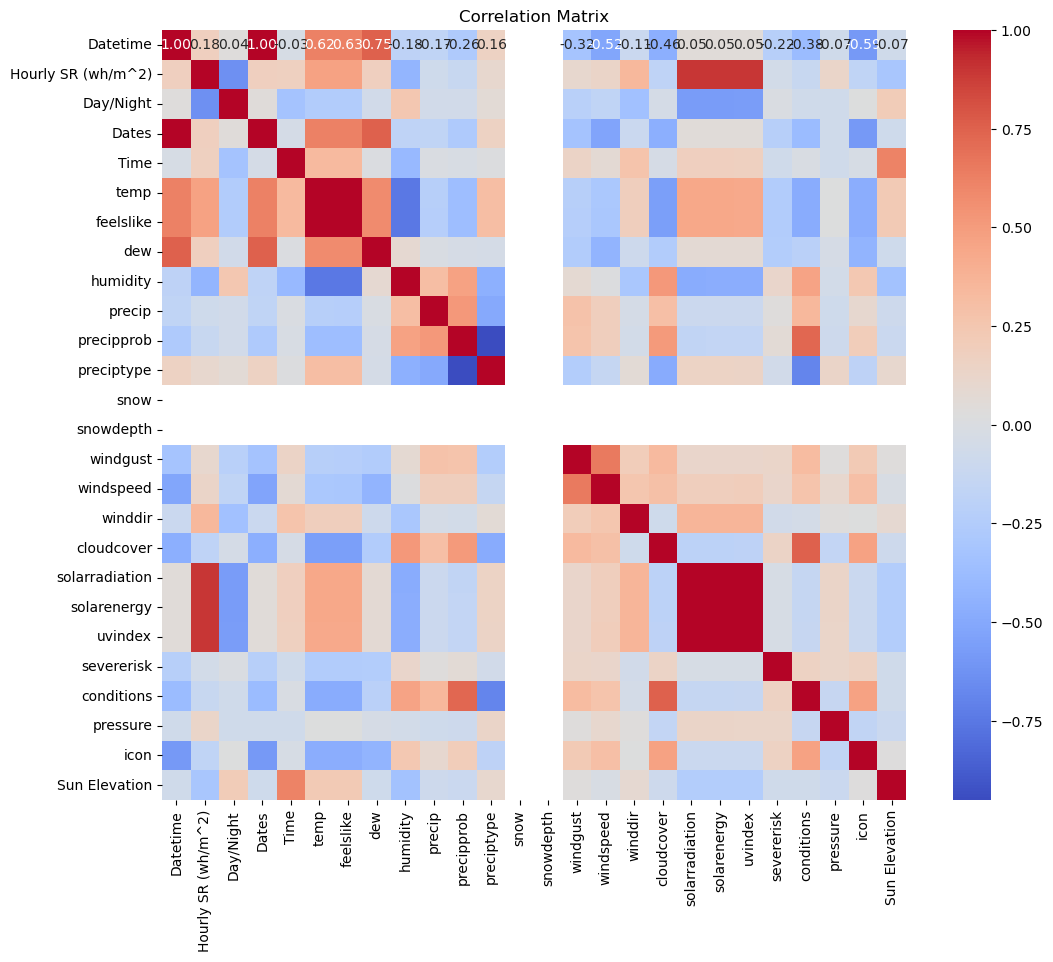

Hourly SR (wh/m^2)    1.000000
solarradiation        0.898059
solarenergy           0.897246
uvindex               0.896539
temp                  0.473490
feelslike             0.472397
winddir               0.348951
dew                   0.181766
Datetime              0.179943
Dates                 0.177742
Time                  0.170554
windspeed             0.138186
pressure              0.124330
windgust              0.108204
preciptype            0.104051
severerisk           -0.053142
precip               -0.078529
conditions           -0.123924
precipprob           -0.124184
icon                 -0.172650
cloudcover           -0.178310
Sun Elevation        -0.305509
humidity             -0.431646
Day/Night            -0.630283
snow                       NaN
snowdepth                  NaN
Name: Hourly SR (wh/m^2), dtype: float64


In [ ]:
# Feature selection
df = pd.DataFrame(test_df)

# Convert categorical variables if any
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Fill missing values with the median
df.fillna(df.median(), inplace=True)

# Analyze correlations
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Focus on correlation with 'Hourly SR (wh/m^2)'
print(correlation_matrix['Hourly SR (wh/m^2)'].sort_values(ascending=False))

In [ ]:
# Set the aesthetics for the plots
sns.set(style="whitegrid")

# Display summary statistics
print("\nSummary statistics of the dataframe:")
print(raw_total_df.describe())



Summary statistics of the dataframe:
                            Datetime  Hourly SR (wh/m^2)  \
count                           1867         1867.000000   
mean   2024-06-29 09:16:58.103910144          110.527373   
min              2024-05-21 00:00:00            0.000000   
25%              2024-06-09 18:30:00            0.000000   
50%              2024-06-29 05:00:00           43.000000   
75%              2024-07-17 15:30:00          206.095000   
max              2024-08-12 15:00:00          766.405000   
std                              NaN          132.456963   

                               Dates         temp    feelslike          dew  \
count                           1867  1867.000000  1867.000000  1867.000000   
mean   2024-06-28 21:54:16.775575808    17.106213    17.082003    11.200321   
min              2024-05-21 00:00:00     8.400000     5.400000     3.300000   
25%              2024-06-09 00:00:00    13.750000    13.750000     9.400000   
50%              2024-06-2

In [ ]:
# Check for missing values
print("\nMissing values in the dataframe:")
print(raw_total_df.isnull().sum())

# Check the data types
print("\nData types of the dataframe columns:")
print(raw_total_df.dtypes)


Missing values in the dataframe:
Datetime                 0
Hourly SR (wh/m^2)       0
Day/Night                0
Dates                    0
Time                     0
temp                     0
feelslike                0
dew                      0
humidity                 0
precip                   0
precipprob               0
preciptype            1631
snow                     0
snowdepth                0
windgust                 0
windspeed                0
winddir                  0
cloudcover               0
solarradiation           0
solarenergy              0
uvindex                  0
severerisk               0
conditions               0
pressure                 0
icon                  1363
Sun Elevation            0
dtype: int64

Data types of the dataframe columns:
Datetime              datetime64[ns]
Hourly SR (wh/m^2)           float64
Day/Night                     object
Dates                 datetime64[ns]
Time                          object
temp                        

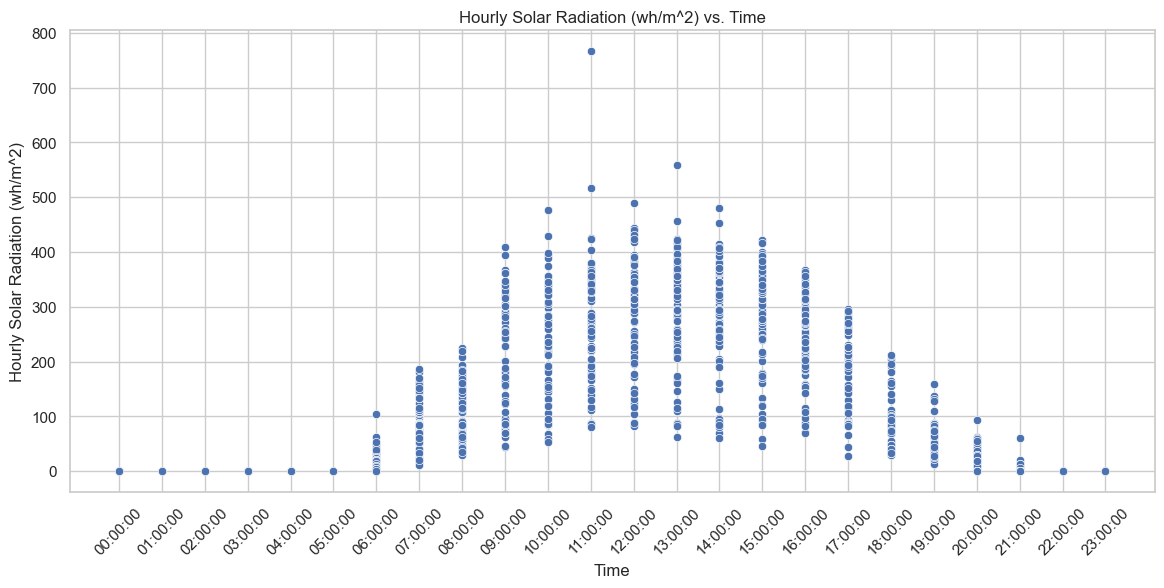

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


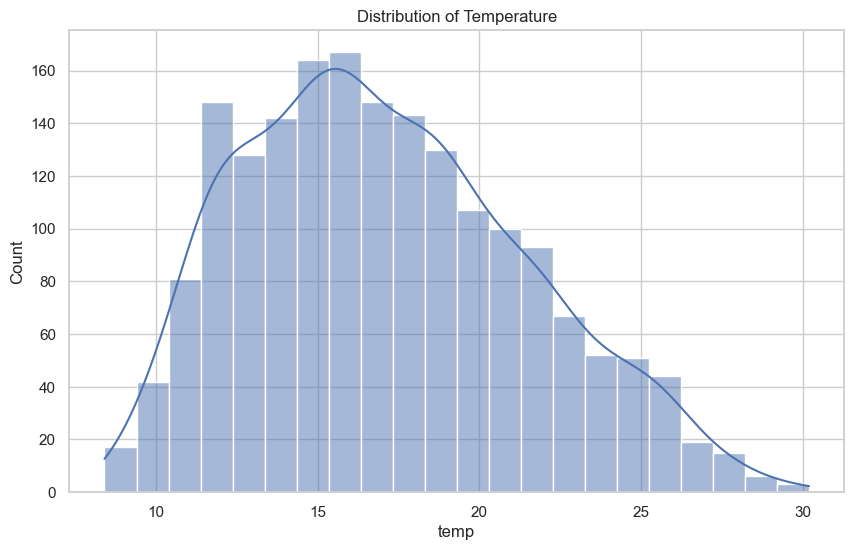

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


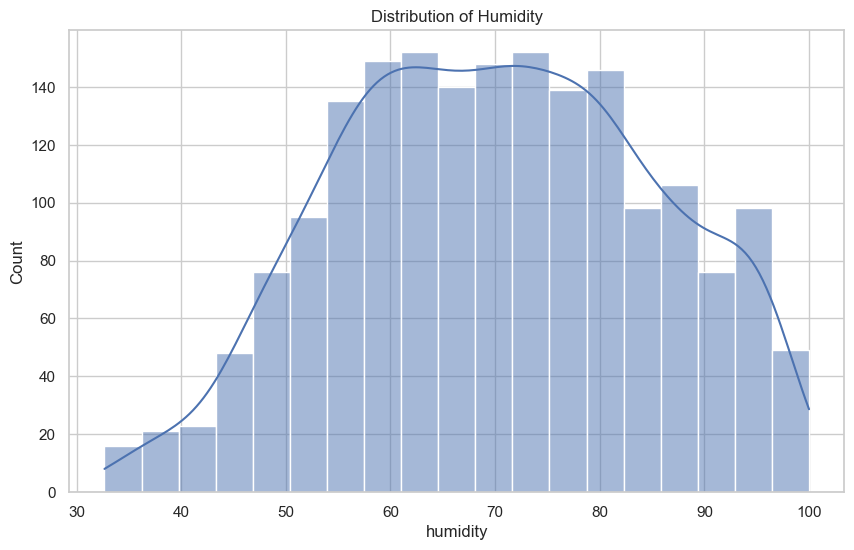

In [ ]:
test_df['Time'] = pd.to_datetime(test_df['Time'], format='%H:%M:%S').dt.time.astype(str)

# Sort by time to ensure a smooth line plot
raw_total_df_sorted = test_df.sort_values(by='Time')
plt.figure(figsize=(14, 6))
sns.scatterplot(x='Time', y='Hourly SR (wh/m^2)', data=test_df)
plt.title('Hourly Solar Radiation (wh/m^2) vs. Time')
plt.xlabel('Time')
plt.ylabel('Hourly Solar Radiation (wh/m^2)')
plt.xticks(rotation=45)
plt.show()

# Distribution of Temperature
plt.figure(figsize=(10, 6))
sns.histplot(test_df['temp'], kde=True)
plt.title('Distribution of Temperature')
plt.show()

# Distribution of Humidity
plt.figure(figsize=(10, 6))
sns.histplot(test_df['humidity'], kde=True)
plt.title('Distribution of Humidity')
plt.show()


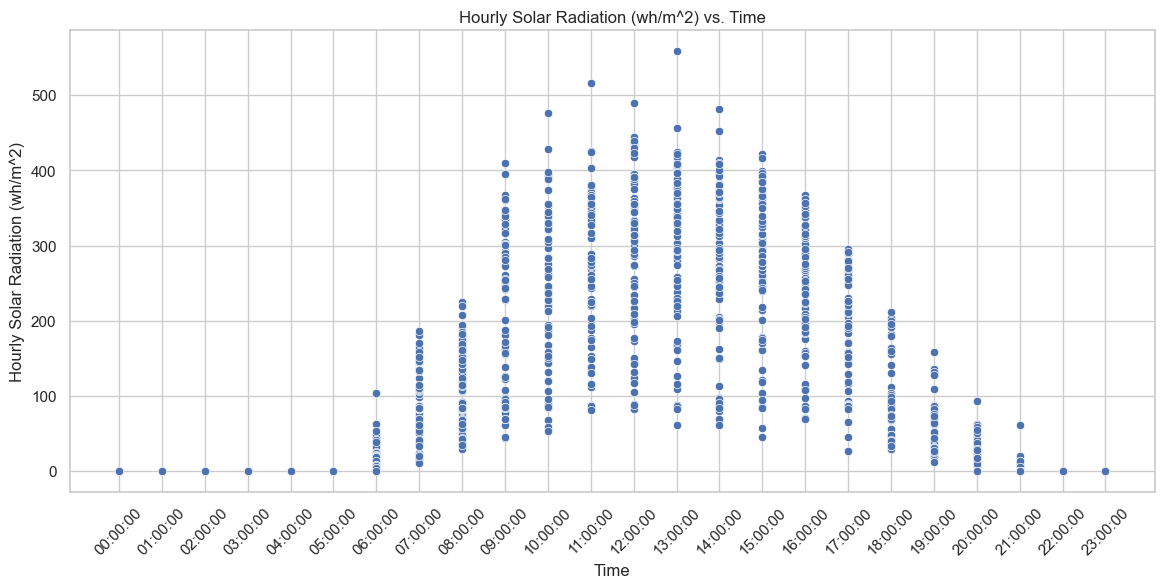

In [ ]:
# Drop outliers
test_df = test_df[test_df['Hourly SR (wh/m^2)'] <= 700]
plt.figure(figsize=(14, 6))
sns.scatterplot(x='Time', y='Hourly SR (wh/m^2)', data=test_df)
plt.title('Hourly Solar Radiation (wh/m^2) vs. Time')
plt.xlabel('Time')
plt.ylabel('Hourly Solar Radiation (wh/m^2)')
plt.xticks(rotation=45)
plt.show()

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


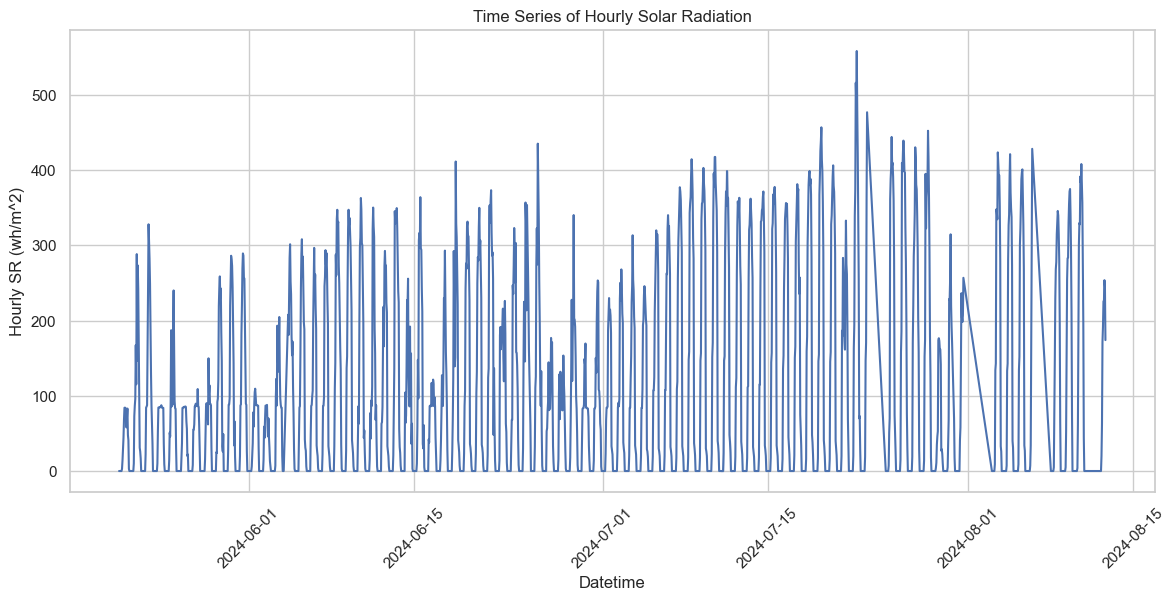

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


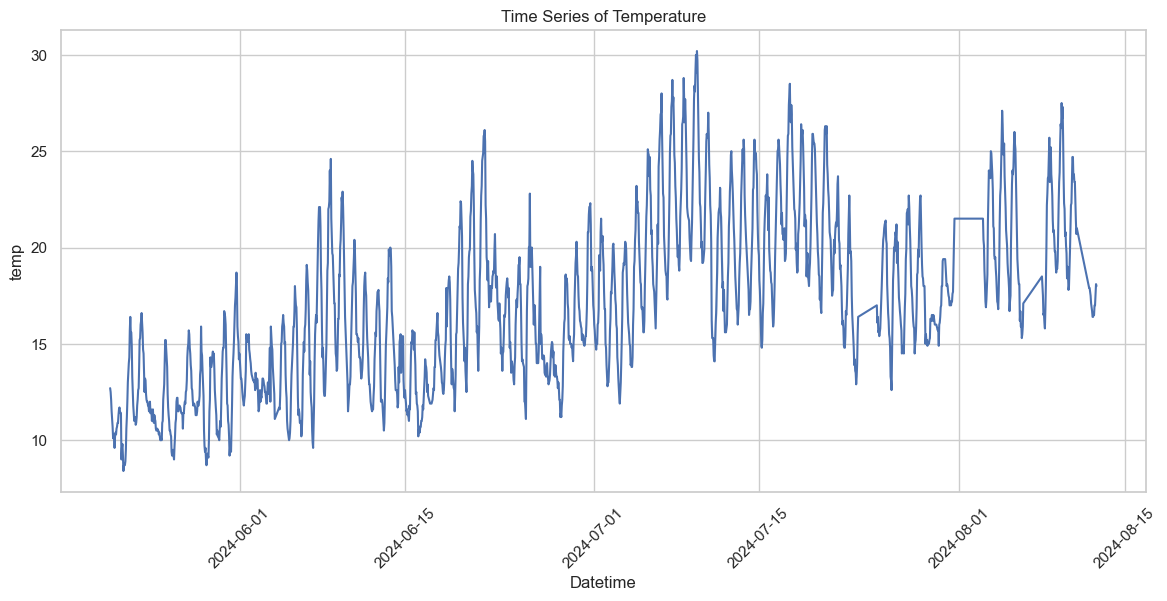

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


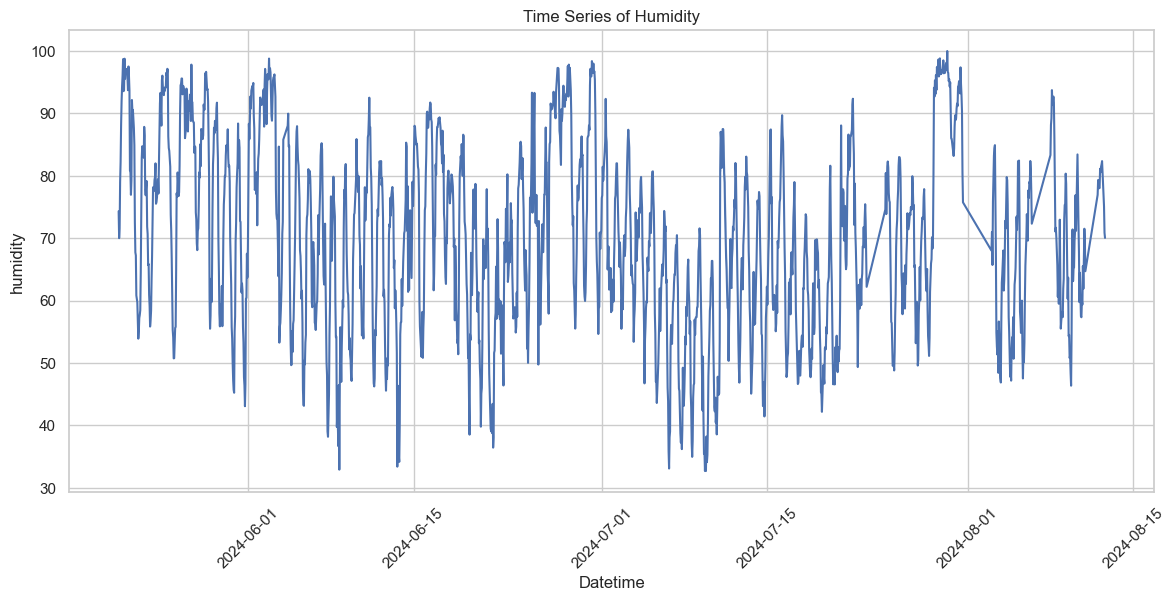

In [ ]:
# Time series plot of Solar Radiation
plt.figure(figsize=(14, 6))
sns.lineplot(x='Datetime', y='Hourly SR (wh/m^2)', data=test_df)
plt.title('Time Series of Hourly Solar Radiation')
plt.xticks(rotation=45)
plt.show()

# Time series plot of Temperature
plt.figure(figsize=(14, 6))
sns.lineplot(x='Datetime', y='temp', data=test_df)
plt.title('Time Series of Temperature')
plt.xticks(rotation=45)
plt.show()

# Time series plot of Humidity
plt.figure(figsize=(14, 6))
sns.lineplot(x='Datetime', y='humidity', data=test_df)
plt.title('Time Series of Humidity')
plt.xticks(rotation=45)
plt.show()



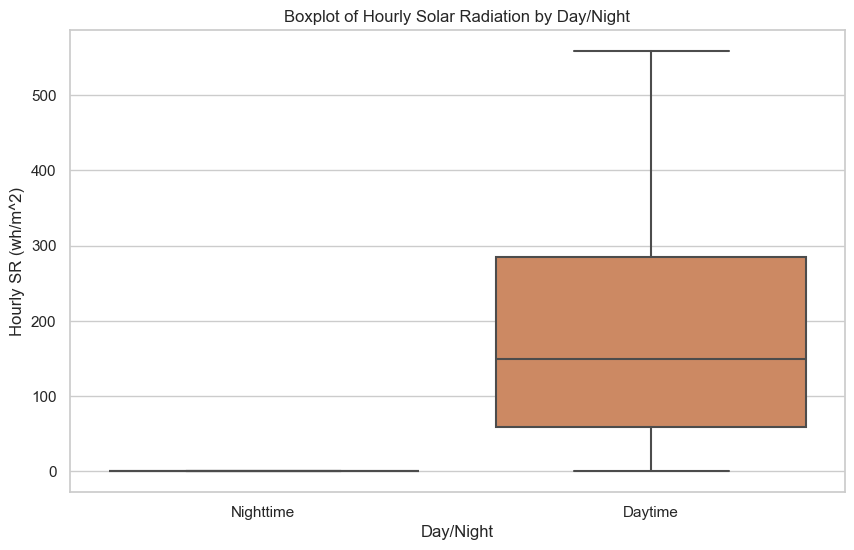

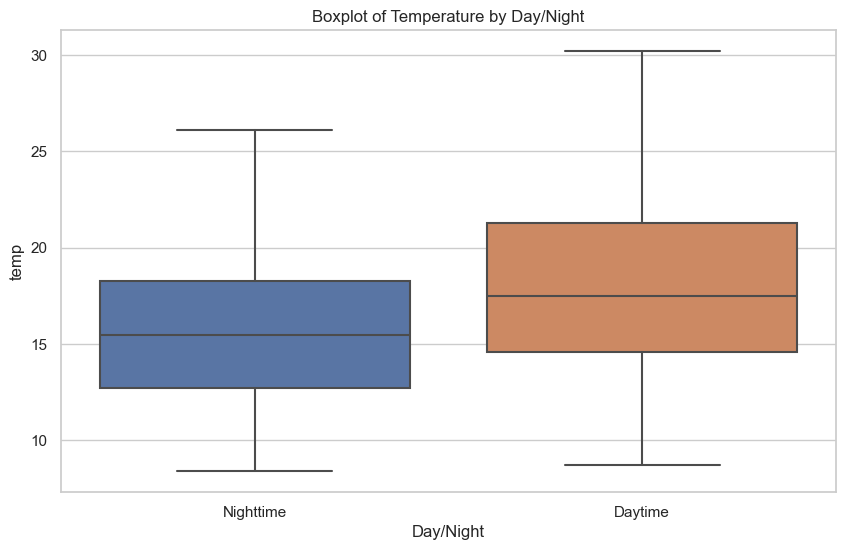

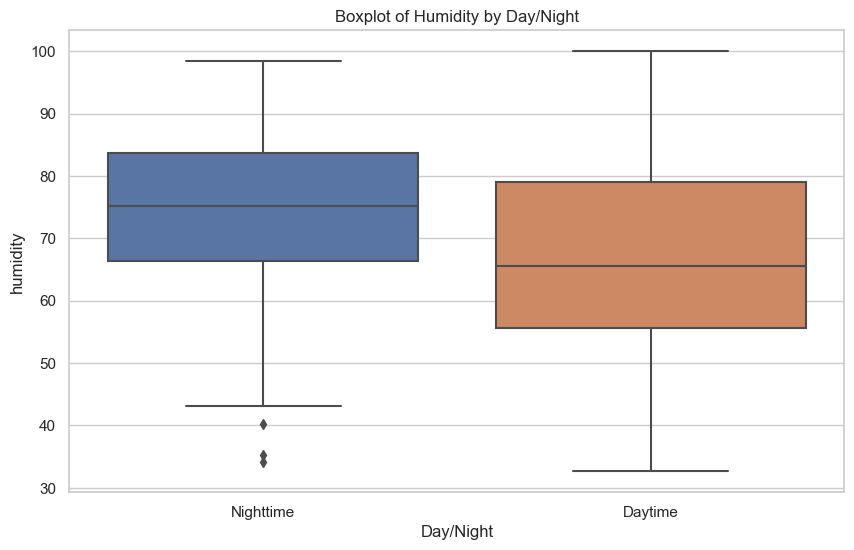

In [ ]:
# Boxplot of Solar Radiation by Day/Night
plt.figure(figsize=(10, 6))
sns.boxplot(x='Day/Night', y='Hourly SR (wh/m^2)', data=test_df)
plt.title('Boxplot of Hourly Solar Radiation by Day/Night')
plt.show()

# Boxplot of Temperature by Day/Night
plt.figure(figsize=(10, 6))
sns.boxplot(x='Day/Night', y='temp', data=test_df)
plt.title('Boxplot of Temperature by Day/Night')
plt.show()

# Boxplot of Humidity by Day/Night
plt.figure(figsize=(10, 6))
sns.boxplot(x='Day/Night', y='humidity', data=test_df)
plt.title('Boxplot of Humidity by Day/Night')
plt.show()


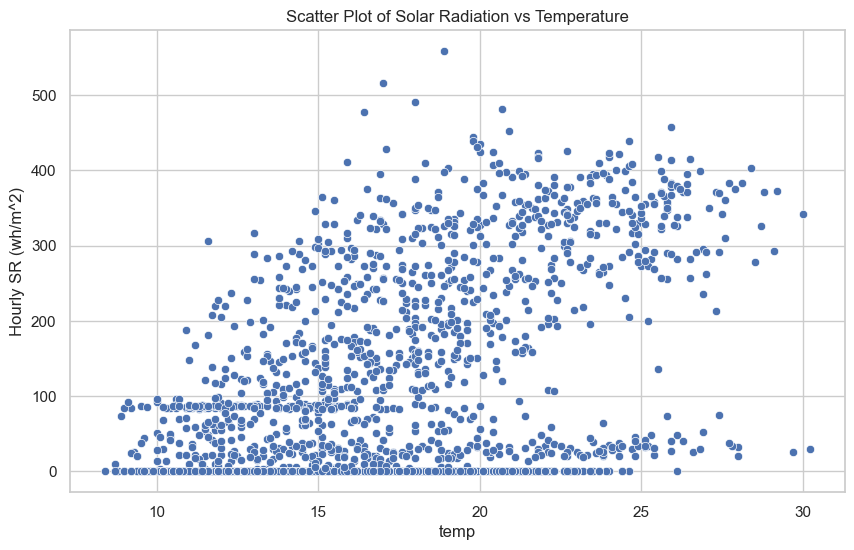

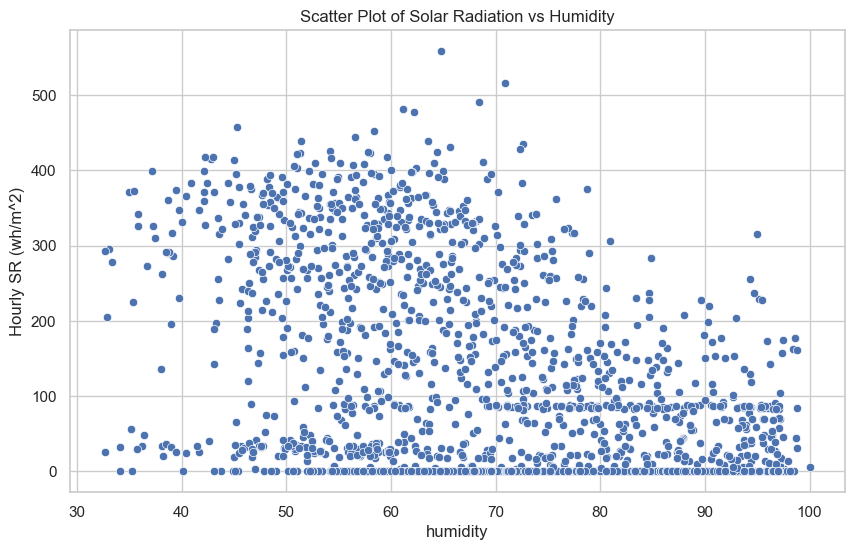

In [ ]:
# Scatter plot of Solar Radiation vs Temperature
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='Hourly SR (wh/m^2)', data=test_df)
plt.title('Scatter Plot of Solar Radiation vs Temperature')
plt.show()

# Scatter plot of Solar Radiation vs Humidity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='humidity', y='Hourly SR (wh/m^2)', data=test_df)
plt.title('Scatter Plot of Solar Radiation vs Humidity')
plt.show()


In [ ]:
test_df['preciptype'] = test_df['preciptype'].fillna(0)
test_df.isna().sum()

/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_32654/1565579200.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['preciptype'] = test_df['preciptype'].fillna(0)


Datetime                 0
Hourly SR (wh/m^2)       0
Day/Night                0
Dates                    0
Time                     0
temp                     0
feelslike                0
dew                      0
humidity                 0
precip                   0
precipprob               0
preciptype               0
snow                     0
snowdepth                0
windgust                 0
windspeed                0
winddir                  0
cloudcover               0
solarradiation           0
solarenergy              0
uvindex                  0
severerisk               0
conditions               0
pressure                 0
icon                  1362
Sun Elevation            0
dtype: int64

In [ ]:
# Remove all nighttime data: since they are all 0
test_df = test_df[test_df['Day/Night'] == 'Daytime']
test_df = test_df.drop(columns=['Day/Night'])
test_df

,Datetime,Hourly SR (wh/m^2),Dates,Time,temp,feelslike,dew,humidity,precip,precipprob,...,winddir,cloudcover,solarradiation,solarenergy,uvindex,severerisk,conditions,pressure,icon,Sun Elevation
6,2024-05-21 06:00:00,3.000,2024-05-21,06:00:00,10.1,10.1,8.9,92.00,1.039,100.0,...,82.0,94.0,3.0,0.0,0.0,10.0,"Rain, Overcast",1016.3,NaN,-14.405989
7,2024-05-21 07:00:00,14.000,2024-05-21,07:00:00,10.3,10.3,9.5,94.38,1.352,100.0,...,93.0,92.0,14.0,0.1,0.0,10.0,"Rain, Overcast",1016.3,NaN,-18.532038
8,2024-05-21 08:00:00,29.000,2024-05-21,08:00:00,10.2,10.2,9.6,96.05,2.239,100.0,...,142.0,100.0,29.0,0.1,0.0,10.0,"Rain, Overcast",1016.3,NaN,-20.320021
9,2024-05-21 09:00:00,44.000,2024-05-21,09:00:00,9.6,7.6,9.4,98.69,3.973,100.0,...,133.0,91.0,44.0,0.2,0.0,10.0,"Rain, Overcast",1016.3,NaN,-19.576858
10,2024-05-21 10:00:00,68.000,2024-05-21,10:00:00,10.2,10.2,9.2,93.56,3.978,100.0,...,130.0,93.0,68.0,0.2,1.0,10.0,"Rain, Overcast",1016.3,NaN,-16.384912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1862,2024-08-12 11:00:00,225.655,2024-08-12,11:00:00,17.0,17.0,13.3,78.52,0.000,0.0,...,172.0,87.0,241.0,0.9,2.0,10.0,Partially cloudy,1016.3,NaN,-16.350805
1863,2024-08-12 12:00:00,226.480,2024-08-12,12:00:00,17.0,17.0,12.8,76.73,0.000,0.0,...,127.0,83.0,275.0,1.0,3.0,10.0,Partially cloudy,1016.3,NaN,-8.994347
1864,2024-08-12 13:00:00,253.795,2024-08-12,13:00:00,17.5,17.5,13.1,75.09,0.000,0.0,...,142.0,72.0,325.0,1.2,3.0,10.0,Partially cloudy,1016.3,NaN,-0.437289
1865,2024-08-12 14:00:00,244.595,2024-08-12,14:00:00,18.1,18.1,12.7,70.86,0.000,0.0,...,180.0,68.0,289.0,1.0,3.0,10.0,Partially cloudy,1016.3,NaN,8.885665


## Method 1: Get Hourly SR and Sum Them Up

In [ ]:
# ANN
ann = MLPRegressor(max_iter=500)

ann_params = {
    'hidden_layer_sizes': [(50, 50), (100, 100), (100,)],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'alpha': [0.0001, 0.001],
}

# RF
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

# CNN
def create_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

cnn_params = {
    'epochs': [10, 20],
    'batch_size': [32, 64],
}


# LR
lr = LinearRegression()
lr_params = {}

# SVM
svm = SVR()

svm_params = {
    'kernel': ['linear', 'rbf'],
    'C': [1, 10],
    'gamma': ['scale', 'auto'],
}


#GBR
gbr = GradientBoostingRegressor(random_state=42)

gbr_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 10],
}

In [ ]:
# Convert 'Time' to hours as a numeric feature (if not done already)
test_df['Time_hour'] = pd.to_datetime(test_df['Time'], format='%H:%M:%S').dt.hour + \
                            pd.to_datetime(test_df['Time'], format='%H:%M:%S').dt.minute / 60


# Features and target
features = ['pressure', 'precip', 'humidity', 'uvindex', 'feelslike', 'temp', 'dew', 'winddir', 'cloudcover', 'Time_hour', 'windspeed', 'windgust', 'Sun Elevation']
target = 'Hourly SR (wh/m^2)'


X = test_df[features]
y = test_df[target]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ANN
grid_ann = GridSearchCV(ann, ann_params, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
grid_ann.fit(X_scaled, y)
best_ann = grid_ann.best_estimator_

# RF
grid_rf = GridSearchCV(rf, rf_params, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_scaled, y)
best_rf = grid_rf.best_estimator_

# CNN (Needs custom handling)
input_shape = (X_scaled.shape[1], 1)
X_scaled_cnn = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

best_cnn_score = float('inf')
for batch_size in cnn_params['batch_size']:
    for epochs in cnn_params['epochs']:
        cnn_model = create_cnn_model(input_shape)
        cnn_model.fit(X_scaled_cnn, y, epochs=epochs, batch_size=batch_size, verbose=0)
        predictions = cnn_model.predict(X_scaled_cnn)
        mse = mean_squared_error(y, predictions)
        if mse < best_cnn_score:
            best_cnn_score = mse
            best_cnn = cnn_model

# LR
grid_lr = GridSearchCV(lr, lr_params, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lr.fit(X_scaled, y)
best_lr = grid_lr.best_estimator_

# SVM
grid_svm = GridSearchCV(svm, svm_params, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
grid_svm.fit(X_scaled, y)
best_svm = grid_svm.best_estimator_

# GBR
grid_gbr = GridSearchCV(gbr, gbr_params, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gbr.fit(X_scaled, y)
best_gbr = grid_gbr.best_estimator_

# Collect all the best models
models = {
    'ANN': best_ann,
    'RF': best_rf,
    'CNN': best_cnn,
    'LR': best_lr,
    'SVM': best_svm,
    'GBR': best_gbr
}



# Evaluate each model
results = []

for model_name, model in models.items():
    if model_name == 'CNN':
        predictions = model.predict(X_scaled_cnn)
    else:
        predictions = model.predict(X_scaled)

    # Calculate MSE and R²
    mse = mean_squared_error(y, predictions)
    r2 = r2_score(y, predictions)

    # Append results to the list
    results.append({
        'Model': model_name,
        'MSE': mse,
        'R²': r2
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display the results
print(results_df)

# Find the best model based on MSE
best_model_name = results_df.loc[results_df['MSE'].idxmin(), 'Model']
best_model_mse = results_df.loc[results_df['MSE'].idxmin(), 'MSE']
best_model_r2 = results_df.loc[results_df['MSE'].idxmin(), 'R²']

print(str(features))
print(f"\nBest Model based on MSE: {best_model_name}")
print(f"MSE: {best_model_mse}")
print(f"R²: {best_model_r2}")




Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.In

/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/shentongli/opt/anaconda3/envs/dsc80/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization

38/38 [==============================] - 0s 1ms/step
  Model          MSE        R²
0   ANN  1440.503259  0.911702
1    RF   291.454348  0.982135
2   CNN  3145.350533  0.807202
3    LR  3197.214866  0.804023
4   SVM  3368.170279  0.793544
5   GBR   130.774869  0.991984
['pressure', 'precip', 'humidity', 'uvindex', 'feelslike', 'temp', 'dew', 'winddir', 'cloudcover', 'Time_hour', 'windspeed', 'windgust', 'Sun Elevation']

Best Model based on MSE: GBR
MSE: 130.77486893631217
R²: 0.9919839859767734


In [ ]:
# Convert 'Dates' to datetime format if it's not already
raw_total_df['Dates'] = pd.to_datetime(raw_total_df['Dates'])

# Define the test period
test_start_date = '2024-06-20'
test_end_date = '2024-06-25'

# Filter the data
train_df = raw_total_df[(raw_total_df['Dates'] < test_start_date) | (raw_total_df['Dates'] > test_end_date)]
test_df = raw_total_df[(raw_total_df['Dates'] >= test_start_date) & (raw_total_df['Dates'] <= test_end_date)]

# Remove nighttime data from both training and testing sets
train_daytime_df = train_df[train_df['Day/Night'] == 'Daytime']
test_daytime_df = test_df[test_df['Day/Night'] == 'Daytime']

# Drop the 'Day/Night' column since it's no longer needed
train_daytime_df = train_daytime_df.drop(columns=['Day/Night'])
test_daytime_df = test_daytime_df.drop(columns=['Day/Night'])


### **GBR**

Test dates: 2024-06-20 to 2024-06-25
GBR
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Daily Error  \
Dates                                                                  
2024-06-20             2944.390             3343.557267   399.167267   
2024-06-21             3440.105             3588.759572   148.654572   
2024-06-22             2307.710             2183.565206  -124.144794   
2024-06-23             2711.520             2531.395452  -180.124548   
2024-06-24             3230.125             2911.246454  -318.878546   
2024-06-25             3135.465             3244.637055   109.172055   

            Absolute Error  Percentage Error (%)  
Dates                                             
2024-06-20      399.167267             13.556875  
2024-06-21      148.654572              4.321222  
2024-06-22      124.144794              5.379567  
2024-06-23      180.124548              6.642936  
2024-06-24      318.878546            

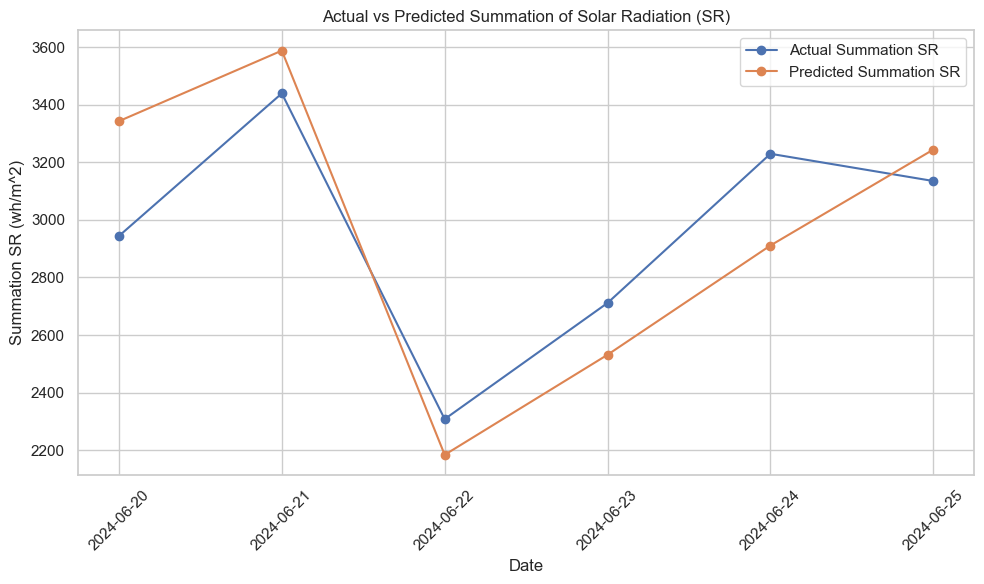

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Features and target for training and testing
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Hourly SR (wh/m^2)'

# Define X and y for training and testing
X_train = train_daytime_df[features]
y_train = train_daytime_df[target]

X_test = test_daytime_df[features]
y_test = test_daytime_df[target]

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train_scaled, y_train)

# Predict hourly SR for the test set
y_pred = gbr.predict(X_test_scaled)

# Add predictions to the test dataframe
test_daytime_df['Predicted Hourly SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for June 10th to June 15th
actual_summation_sr = test_daytime_df.groupby('Dates')['Hourly SR (wh/m^2)'].sum()
predicted_summation_sr = test_daytime_df.groupby('Dates')['Predicted Hourly SR (wh/m^2)'].sum()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']

# Optionally, you can calculate the absolute error or percentage error as well
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100
comparison_df.drop(columns=['Daily Error'])

# Display the updated comparison dataframe with errors
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('GBR')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: '+str(comparison_df['Absolute Error'].mean()))



plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

### **Random Forest**

Test dates: 2024-07-08 to 2024-07-13
RF
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Daily Error  \
Dates                                                                  
2024-07-08             3649.120             3441.558463  -207.561537   
2024-07-09             3623.895             3465.536069  -158.358931   
2024-07-10             3774.835             3394.674174  -380.160826   
2024-07-11             7004.580             6160.179383  -844.400617   
2024-07-12             3188.240             3282.760005    94.520005   
2024-07-13             3150.020             3302.793174   152.773174   

            Absolute Error  Percentage Error (%)  
Dates                                             
2024-07-08      207.561537              5.687989  
2024-07-09      158.358931              4.369854  
2024-07-10      380.160826             10.070926  
2024-07-11      844.400617             12.054979  
2024-07-12       94.520005             

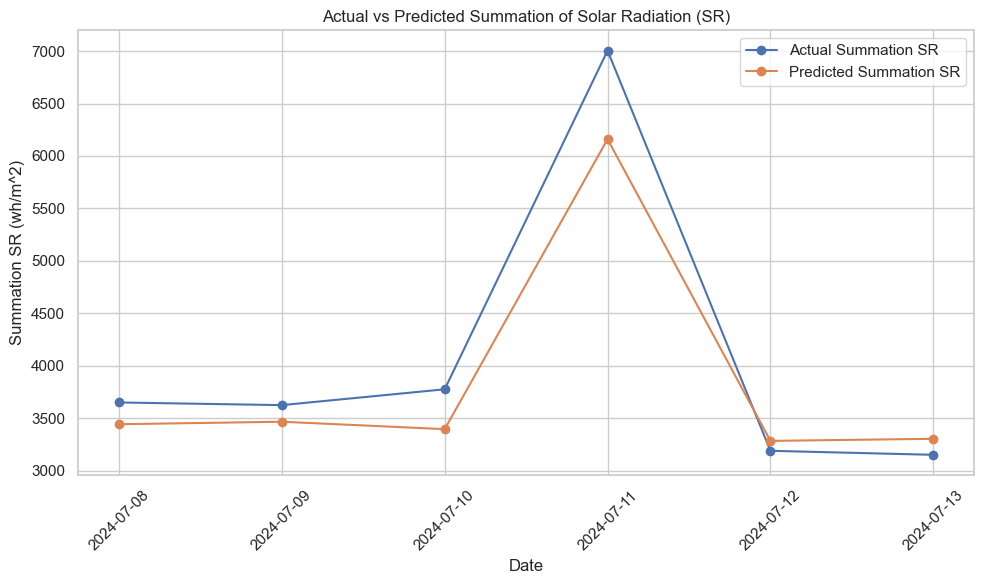

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Features and target for training and testing
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Hourly SR (wh/m^2)'

# Define X and y for training and testing
X_train = train_daytime_df[features]
y_train = train_daytime_df[target]

X_test = test_daytime_df[features]
y_test = test_daytime_df[target]

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict hourly SR for the test set
y_pred = rf.predict(X_test_scaled)

# Add predictions to the test dataframe
test_daytime_df['Predicted Hourly SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for June 10th to June 15th
actual_summation_sr = test_daytime_df.groupby('Dates')['Hourly SR (wh/m^2)'].sum()
predicted_summation_sr = test_daytime_df.groupby('Dates')['Predicted Hourly SR (wh/m^2)'].sum()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']

# Optionally, you can calculate the absolute error or percentage error as well
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100
comparison_df.drop(columns=['Daily Error'])

# Display the updated comparison dataframe with errors
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('RF')
print(str(features))
print(comparison_df)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


### **ANN**

Test dates: 2024-05-20 to 2024-05-25
ANN
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Daily Error  \
Dates                                                                  
2024-06-20             2944.390             3195.769991   251.379991   
2024-06-21             3440.105             3462.477590    22.372590   
2024-06-22             2307.710             2217.942764   -89.767236   
2024-06-23             2711.520             2354.624053  -356.895947   
2024-06-24             3230.125             2759.136529  -470.988471   
2024-06-25             3135.465             2983.545910  -151.919090   

            Absolute Error  Percentage Error (%)  
Dates                                             
2024-06-20      251.379991              8.537592  
2024-06-21       22.372590              0.650346  
2024-06-22       89.767236              3.889884  
2024-06-23      356.895947             13.162210  
2024-06-24      470.988471            

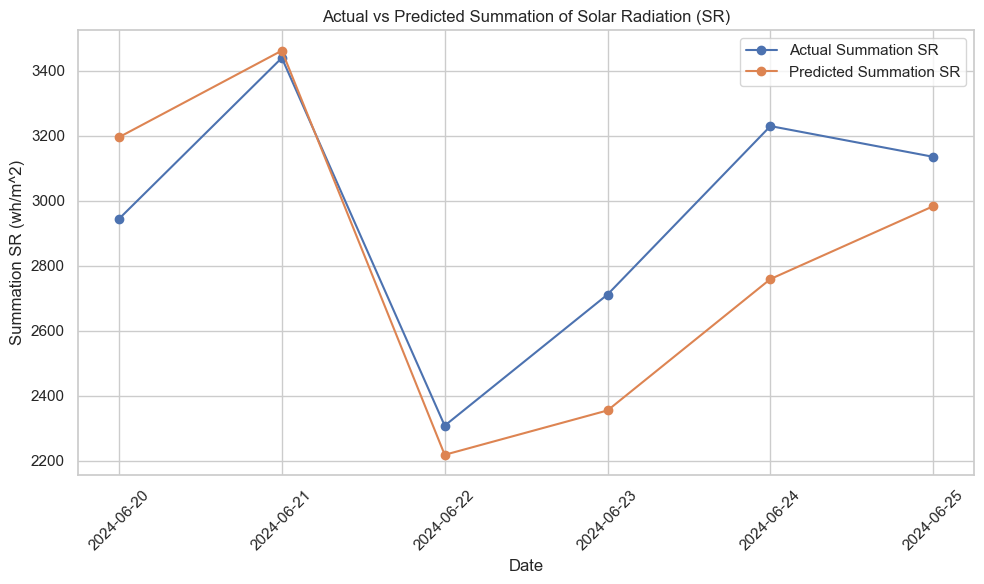

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Features and target for training and testing
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Hourly SR (wh/m^2)'

# Define X and y for training and testing
X_train = train_daytime_df[features]
y_train = train_daytime_df[target]

X_test = test_daytime_df[features]
y_test = test_daytime_df[target]

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the ANN model
ann = MLPRegressor(hidden_layer_sizes=(100, 100), learning_rate_init=0.01, max_iter=500, random_state=42)
ann.fit(X_train_scaled, y_train)

# Predict hourly SR for the test set
y_pred = ann.predict(X_test_scaled)

# Add predictions to the test dataframe
test_daytime_df['Predicted Hourly SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for June 10th to June 15th
actual_summation_sr = test_daytime_df.groupby('Dates')['Hourly SR (wh/m^2)'].sum()
predicted_summation_sr = test_daytime_df.groupby('Dates')['Predicted Hourly SR (wh/m^2)'].sum()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']

# Optionally, you can calculate the absolute error or percentage error as well
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100
comparison_df.drop(columns=['Daily Error'])

# Display the updated comparison dataframe with errors
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('ANN')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: '+str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


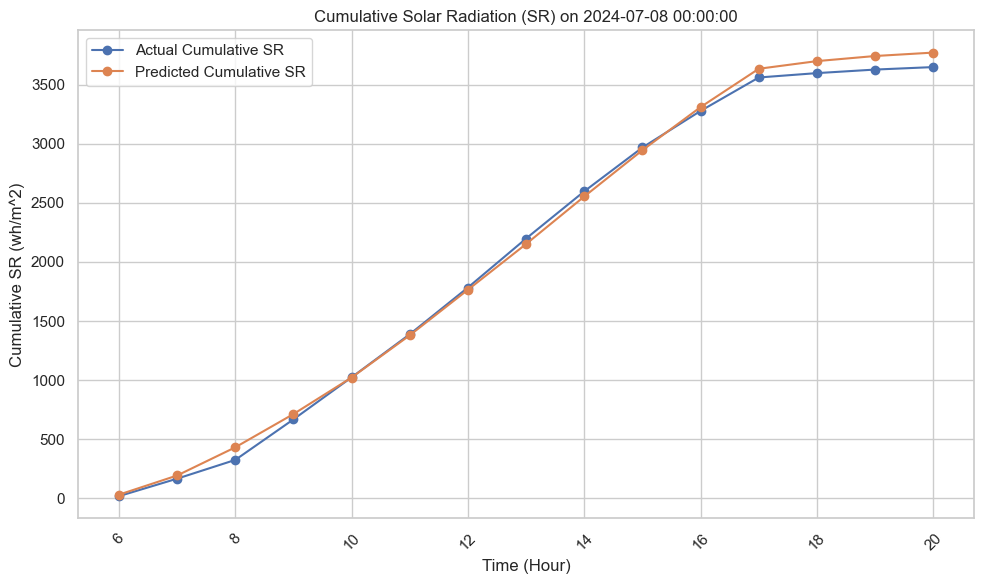

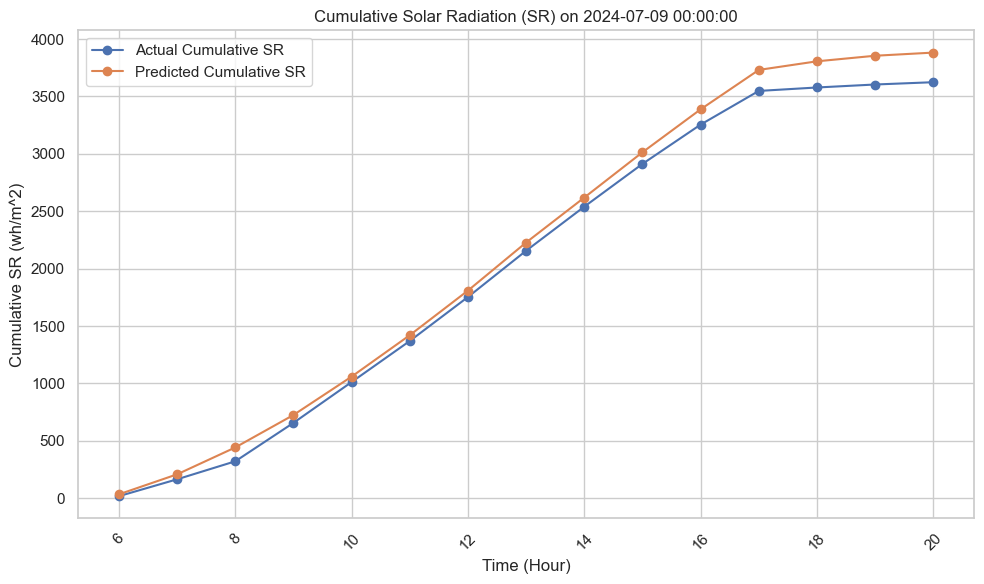

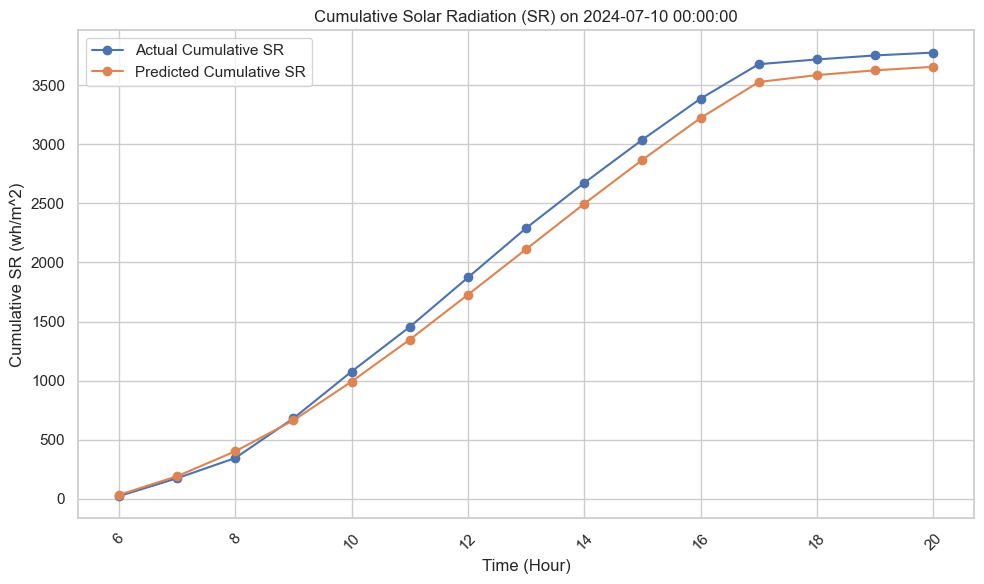

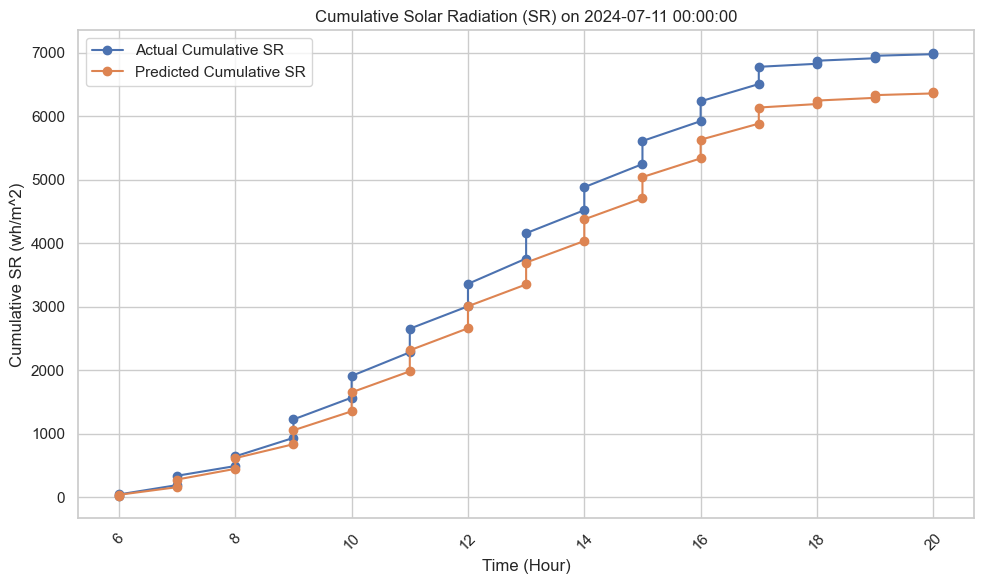

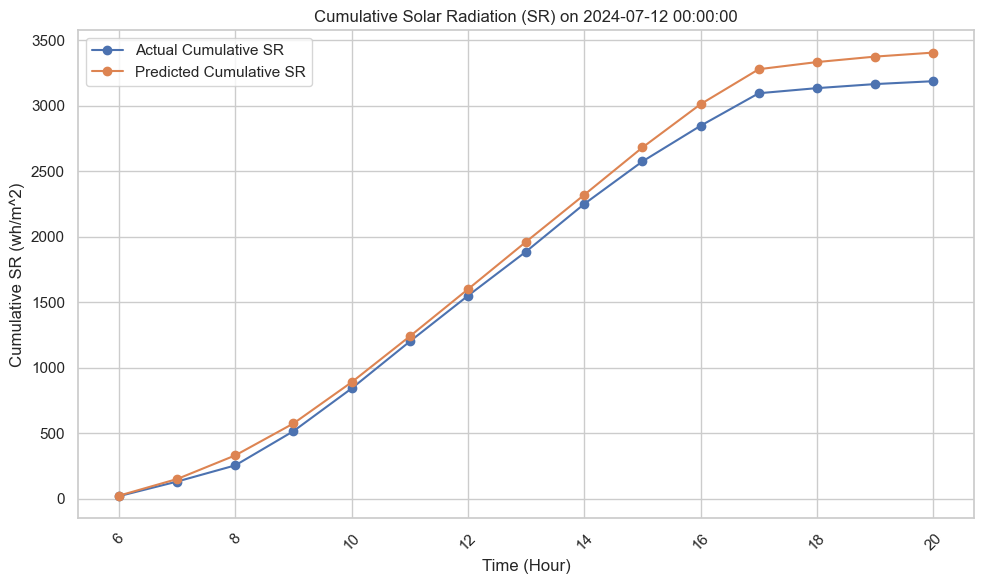

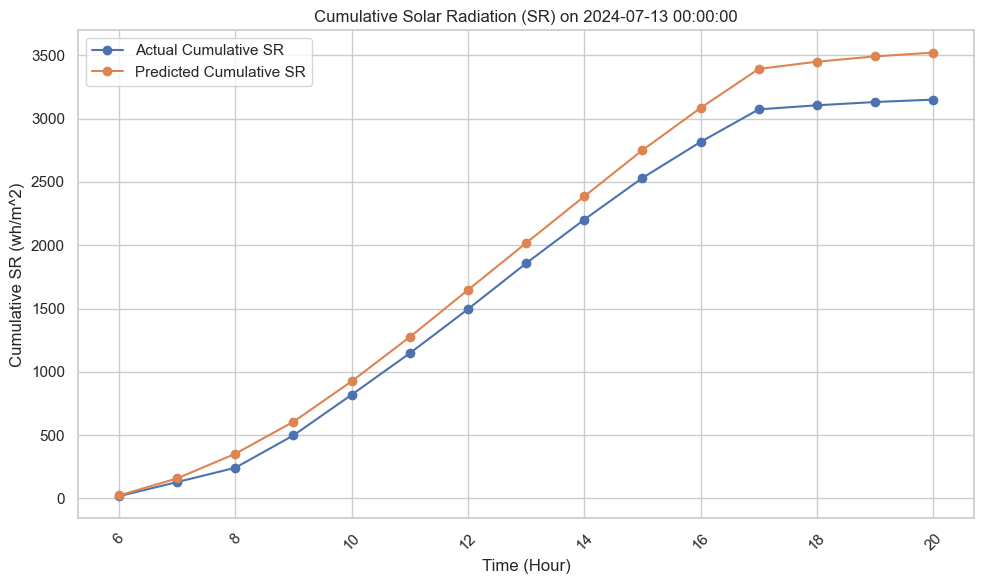

In [ ]:
# draw daily
for date in test_daytime_df['Dates'].unique():
    # Filter data for the specific date
    daily_data = test_daytime_df[test_daytime_df['Dates'] == date].copy()

    # Calculate cumulative SR for actual and predicted values
    daily_data['Actual Cumulative SR'] = daily_data['Hourly SR (wh/m^2)'].cumsum()
    daily_data['Predicted Cumulative SR'] = daily_data['Predicted Hourly SR (wh/m^2)'].cumsum()

    # Plot the comparison for the specific day
    plt.figure(figsize=(10, 6))

    plt.plot(daily_data['Time_hour'], daily_data['Actual Cumulative SR'], label='Actual Cumulative SR', marker='o')
    plt.plot(daily_data['Time_hour'], daily_data['Predicted Cumulative SR'], label='Predicted Cumulative SR', marker='o')

    plt.title(f'Cumulative Solar Radiation (SR) on {date}')
    plt.xlabel('Time (Hour)')
    plt.ylabel('Cumulative SR (wh/m^2)')
    plt.xticks(rotation=45)
    plt.legend()

    plt.tight_layout()
    plt.show()

### **CNN**

3/3 [==============================] - 0s 1ms/step
Test dates: 2024-06-20 to 2024-06-25
CNN
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Absolute Error  \
Dates                                                                     
2024-06-20             2944.390             3325.547119      381.157119   
2024-06-21             3440.105             3623.816162      183.711162   
2024-06-22             2307.710             2170.374023      137.335977   
2024-06-23             2711.520             2418.520508      292.999492   
2024-06-24             3230.125             2895.297852      334.827148   
2024-06-25             3135.465             3093.875977       41.589023   

            Percentage Error (%)  
Dates                             
2024-06-20             12.945198  
2024-06-21              5.340278  
2024-06-22              5.951180  
2024-06-23             10.805729  
2024-06-24             10.365764  
2024-06-25              

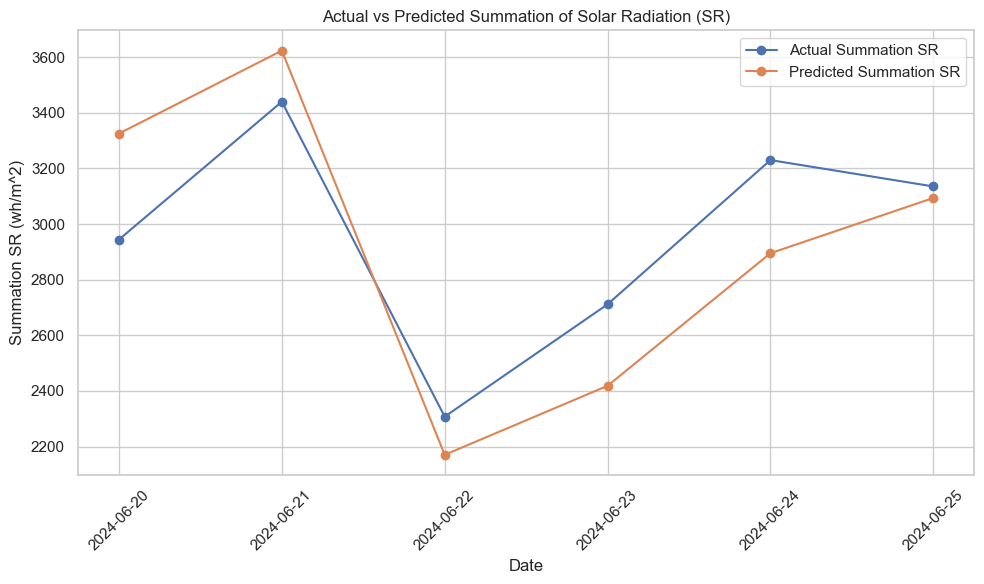

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout
from sklearn.preprocessing import StandardScaler


random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
random.seed(random_seed)

# Features and target for training and testing
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Hourly SR (wh/m^2)'

# Define X and y for training and testing
X_train = train_daytime_df[features]
y_train = train_daytime_df[target]

X_test = test_daytime_df[features]
y_test = test_daytime_df[target]

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape the data to fit the CNN input (samples, time steps, features)
X_train_scaled_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_scaled_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Build the CNN model
cnn = Sequential()
cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_scaled_cnn.shape[1], 1)))
cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
cnn.add(Flatten())
cnn.add(Dense(100, activation='relu'))
cnn.add(Dropout(0.2))
cnn.add(Dense(1))

# Compile the model
cnn.compile(optimizer='adam', loss='mse')

# Train the CNN model
cnn.fit(X_train_scaled_cnn, y_train, epochs=100, batch_size=64, verbose=0)

# Predict hourly SR for the test set
y_pred = cnn.predict(X_test_scaled_cnn).flatten()

# Add predictions to the test dataframe
test_daytime_df['Predicted Hourly SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for June 10th to June 15th
actual_summation_sr = test_daytime_df.groupby('Dates')['Hourly SR (wh/m^2)'].sum()
predicted_summation_sr = test_daytime_df.groupby('Dates')['Predicted Hourly SR (wh/m^2)'].sum()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']

# Optionally, you can calculate the absolute error or percentage error as well
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100
comparison_df.drop(columns=['Daily Error'], inplace=True)

# Display the updated comparison dataframe with errors
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('CNN')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: ' + str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


### **SVM**

Test dates: 2024-05-20 to 2024-05-25
SVM
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Absolute Error  \
Dates                                                                     
2024-06-20             2944.390             3284.438496      340.048496   
2024-06-21             3440.105             3546.613661      106.508661   
2024-06-22             2307.710             2098.889677      208.820323   
2024-06-23             2711.520             2310.445503      401.074497   
2024-06-24             3230.125             2716.213565      513.911435   
2024-06-25             3135.465             3050.954069       84.510931   

            Percentage Error (%)  
Dates                             
2024-06-20             11.549030  
2024-06-21              3.096088  
2024-06-22              9.048811  
2024-06-23             14.791501  
2024-06-24             15.909955  
2024-06-25              2.695324  
Average Daily Absolute Error: 275.812390

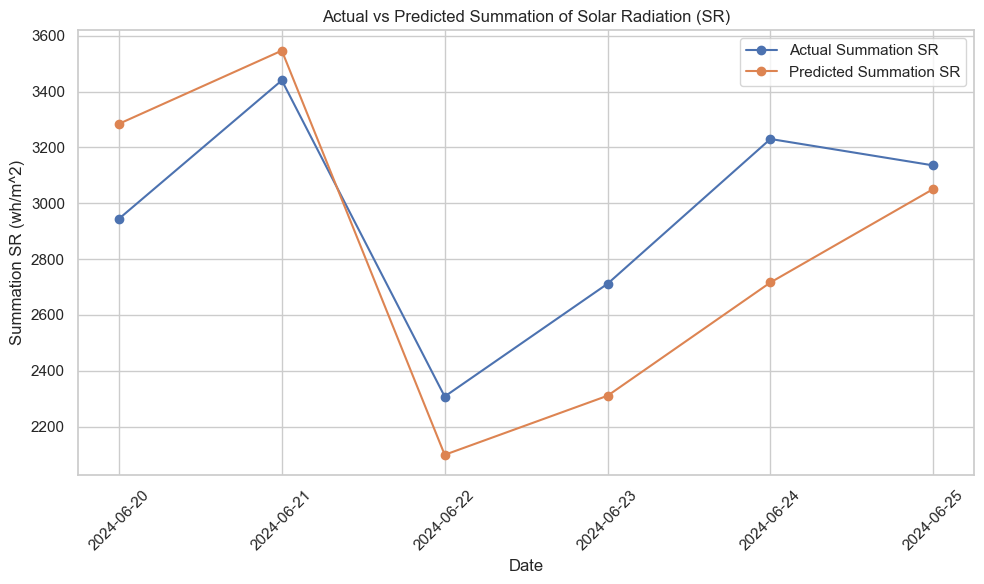

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Features and target for training and testing
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Hourly SR (wh/m^2)'

# Define X and y for training and testing
X_train = train_daytime_df[features]
y_train = train_daytime_df[target]

X_test = test_daytime_df[features]
y_test = test_daytime_df[target]

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVM model
svm = SVR(kernel='rbf', C=50, gamma='scale', epsilon=0.1)
svm.fit(X_train_scaled, y_train)

# Predict hourly SR for the test set
y_pred = svm.predict(X_test_scaled)

# Add predictions to the test dataframe
test_daytime_df['Predicted Hourly SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for June 10th to June 15th
actual_summation_sr = test_daytime_df.groupby('Dates')['Hourly SR (wh/m^2)'].sum()
predicted_summation_sr = test_daytime_df.groupby('Dates')['Predicted Hourly SR (wh/m^2)'].sum()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']

# Optionally, you can calculate the absolute error or percentage error as well
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100
comparison_df.drop(columns=['Daily Error'], inplace=True)

# Display the updated comparison dataframe with errors
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('SVM')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: ' + str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


> Though all models performs well. I want to improve the accuracy and model selection process.


## Model Selection
### Classify the input data and choose the best model for each group

In [3]:
raw_total_df = pd.read_csv('/0815_raw_total_df.csv')
test_df = pd.read_csv('/test_df.csv')
# Convert 'Dates' to datetime format if it's not already
raw_total_df['Dates'] = pd.to_datetime(raw_total_df['Dates'])
raw_total_df['Time_hour'] = pd.to_datetime(raw_total_df['Time'], format='%H:%M:%S').dt.hour + \
                            pd.to_datetime(raw_total_df['Time'], format='%H:%M:%S').dt.minute / 60


In [4]:
predicted_uv_fl_0711 = pd.read_csv('/weather_prediction_till_2024-07-26.csv')
predicted_uv_fl_0807 = pd.read_csv('/weather_prediction_till_2024-08-09.csv')
predicted_uv_fl_0802 = pd.read_csv('/weather_prediction_till_2024-08-02.csv')
predicted_total_uv_fl = pd.concat([predicted_uv_fl_0711, predicted_uv_fl_0807, predicted_uv_fl_0802])
predicted_total_uv_fl

,Dates,Time,temp,tempmax,tempmin,feelslike,feelslikemax,feelslikemin,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,Sun Angle
0,2024-07-11,2024-07-10 00:00:00,18.7,24.2,15.6,18.7,24.2,15.6,14.4,76.07,...,0.0,0.0,10.0,05:20:01,21:15:43,0.19,Clear,Clear conditions throughout the day.,clear-day,37.986672
1,2024-07-11,2024-07-10 01:00:00,18.0,24.2,15.6,18.0,24.2,15.6,14.0,77.46,...,0.0,0.0,10.0,05:20:01,21:15:43,0.19,Clear,Clear conditions throughout the day.,clear-day,28.243481
2,2024-07-11,2024-07-10 02:00:00,17.5,24.2,15.6,17.5,24.2,15.6,13.7,78.39,...,0.0,0.0,10.0,05:20:01,21:15:43,0.19,Clear,Clear conditions throughout the day.,clear-day,18.551134
3,2024-07-11,2024-07-10 03:00:00,16.7,24.2,15.6,16.7,24.2,15.6,13.7,82.47,...,0.0,0.0,10.0,05:20:01,21:15:43,0.19,Clear,Clear conditions throughout the day.,clear-day,9.255664
4,2024-07-11,2024-07-10 04:00:00,16.3,24.2,15.6,16.3,24.2,15.6,13.7,84.59,...,0.0,0.0,10.0,05:20:01,21:15:43,0.19,Clear,Clear conditions throughout the day.,clear-day,0.688006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2024-08-02,2024-08-01 19:00:00,25.9,28.1,17.9,25.9,28.6,17.9,16.4,55.80,...,1.0,3.0,10.0,05:46:48,20:49:45,0.94,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,55.144688
68,2024-08-02,2024-08-01 20:00:00,24.8,28.1,17.9,24.8,28.6,17.9,16.2,58.82,...,0.4,1.0,10.0,05:46:48,20:49:45,0.94,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,58.266776
69,2024-08-02,2024-08-01 21:00:00,23.7,28.1,17.9,23.7,28.6,17.9,16.1,62.43,...,0.3,0.0,10.0,05:46:48,20:49:45,0.94,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,56.941612
70,2024-08-02,2024-08-01 22:00:00,22.5,28.1,17.9,22.5,28.6,17.9,15.9,66.28,...,0.2,0.0,10.0,05:46:48,20:49:45,0.94,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,51.653107


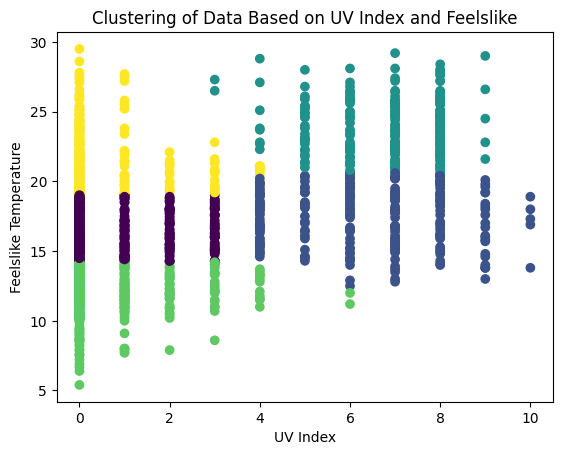

In [5]:
# Define the features for clustering
clustering_features = raw_total_df[['uvindex', 'feelslike']].dropna()

# Perform K-Means clustering with n_init set explicitly
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # Explicitly set n_init to 10
raw_total_df['Cluster'] = kmeans.fit_predict(clustering_features)

# Visualize the clusters
plt.scatter(raw_total_df['uvindex'], raw_total_df['feelslike'], c=raw_total_df['Cluster'], cmap='viridis')
plt.xlabel('UV Index')
plt.ylabel('Feelslike Temperature')
plt.title('Clustering of Data Based on UV Index and Feelslike')
plt.show()



In [9]:
# Define the test period
test_start_date = '2024-06-25'
test_end_date = test_start_date

# Filter the data
train_df = raw_total_df[(raw_total_df['Dates'] < test_start_date) | (raw_total_df['Dates'] > test_end_date)]
test_df = raw_total_df[(raw_total_df['Dates'] >= test_start_date) & (raw_total_df['Dates'] <= test_end_date)]

# Remove nighttime data from both training and testing sets
train_daytime_df = train_df[train_df['Day/Night'] == 'Daytime']
test_daytime_df = test_df[test_df['Day/Night'] == 'Daytime']

# Drop the 'Day/Night' column since it's no longer needed
train_daytime_df = train_daytime_df.drop(columns=['Day/Night'])
test_daytime_df = test_daytime_df.drop(columns=['Day/Night'])

In [10]:
# Add k-fold, parameter tuning
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error

# Define the models with their respective parameter grids
models = {
    'ANN': {
        'model': MLPRegressor(random_state=42, early_stopping=True),
        'param_grid': {
            'hidden_layer_sizes': [(100, 100), (50, 50)],
            'learning_rate_init': [0.01, 0.001],
            'max_iter': [500, 1000]
        }
    },
    'GBR': {
        'model': GradientBoostingRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [100, 200],
            'learning_rate': [0.1, 0.05],
            'max_depth': [3, 5]
        }
    },
    'SVM': {
        'model': SVR(),
        'param_grid': {
            'C': [10, 50, 100],
            'gamma': ['scale', 'auto'],
            'epsilon': [0.1, 0.01]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10]
        }
    }
}

# Initialize a dictionary to store the best model for each cluster
best_models = {}

# Iterate through each cluster
for cluster in raw_total_df['Cluster'].unique():
    print(f"Evaluating models for Cluster {cluster}")

    # Subset the data for the current cluster in the training set
    cluster_train_data = train_daytime_df[train_daytime_df['Cluster'] == cluster]

    # Define features and target
    X_train = cluster_train_data[['Time_hour', 'uvindex', 'feelslike']]
    y_train = cluster_train_data['Hourly SR (wh/m^2)']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Track the best model and score for this cluster
    best_model = None
    best_score = np.inf

    # Evaluate each model with GridSearchCV for tuning and cross-validation
    for model_name, model_info in models.items():
        grid_search = GridSearchCV(
            model_info['model'],
            model_info['param_grid'],
            cv=KFold(n_splits=5, shuffle=True, random_state=42),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train)

        # Get the best model and its score
        best_estimator = grid_search.best_estimator_
        best_mse = -grid_search.best_score_

        # Compare scores to find the best model for this cluster
        if best_mse < best_score:
            best_score = best_mse
            best_model = best_estimator

    # Store the best model and scaler for this cluster
    best_models[cluster] = {'model': best_model, 'scaler': scaler}

    print(f"Best model for Cluster {cluster}: {type(best_model).__name__} with MSE: {best_score}")

# Display the best model for each cluster
print("\nBest models for each cluster:")
for cluster, info in best_models.items():
    print(f"Cluster {cluster}: {type(info['model']).__name__}")

# Initialize a dictionary to store the final best model and scaler
final_models = {}

# Combine all training data across clusters
combined_train_data = train_daytime_df.dropna(subset=['Hourly SR (wh/m^2)', 'Time_hour', 'uvindex', 'feelslike']).copy()

# Define features and target for the combined training data
X_train_combined = combined_train_data[['Time_hour', 'uvindex', 'feelslike']]
y_train_combined = combined_train_data['Hourly SR (wh/m^2)']

# Iterate through each cluster to train the best model on the entire training data
for cluster in best_models.keys():
    print(f"Training the final model for Cluster {cluster} using all data")

    # Retrieve the best model
    best_model = best_models[cluster]['model']

    # Scale the combined training features
    scaler = StandardScaler()
    X_train_combined_scaled = scaler.fit_transform(X_train_combined)

    # Train the model on the combined training data
    best_model.fit(X_train_combined_scaled, y_train_combined)

    # Store the final model and scaler for this cluster
    final_models[cluster] = {'model': best_model, 'scaler': scaler}

    print(f"Final model for Cluster {cluster} trained on all data.")


Evaluating models for Cluster 3
Best model for Cluster 3: MLPRegressor with MSE: 1555.0408883269788
Evaluating models for Cluster 1
Best model for Cluster 1: GradientBoostingRegressor with MSE: 6621.759819454247
Evaluating models for Cluster 0
Best model for Cluster 0: SVR with MSE: 2316.862902092978
Evaluating models for Cluster 2
Best model for Cluster 2: RandomForestRegressor with MSE: 1948.7599798222968
Evaluating models for Cluster 4
Best model for Cluster 4: RandomForestRegressor with MSE: 1969.22996417399

Best models for each cluster:
Cluster 3: MLPRegressor
Cluster 1: GradientBoostingRegressor
Cluster 0: SVR
Cluster 2: RandomForestRegressor
Cluster 4: RandomForestRegressor
Training the final model for Cluster 3 using all data
Final model for Cluster 3 trained on all data.
Training the final model for Cluster 1 using all data
Final model for Cluster 1 trained on all data.
Training the final model for Cluster 0 using all data
Final model for Cluster 0 trained on all data.
Traini

In [ ]:
# Simple model selection
models = {
    'ANN': MLPRegressor(hidden_layer_sizes=(100, 100), learning_rate_init=0.01, max_iter=500, random_state=42, early_stopping=True),
    'GBR': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'SVM': SVR(kernel='rbf', C=50, gamma='scale', epsilon=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
}

# Initialize a dictionary to store the best model for each cluster
best_models = {}

# Iterate through each cluster
for cluster in raw_total_df['Cluster'].unique():
    print(f"Evaluating models for Cluster {cluster}")

    # Subset the data for the current cluster in the training set
    cluster_train_data = train_daytime_df[train_daytime_df['Cluster'] == cluster]

    # Define features and target
    X_train = cluster_train_data[['Time_hour', 'uvindex', 'feelslike']]
    y_train = cluster_train_data['Hourly SR (wh/m^2)']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Track the best model and score for this cluster
    best_model = None
    best_score = np.inf

    # Evaluate each model
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train_scaled, y_train)

        # Evaluate the model on the training data
        y_train_pred = model.predict(X_train_scaled)
        mse = mean_squared_error(y_train, y_train_pred)

        # Compare scores to find the best model for this cluster
        if mse < best_score:
            best_score = mse
            best_model = model_name

    # Store the best model and scaler for this cluster
    best_models[cluster] = {'model_name': best_model, 'scaler': scaler}

    print(f"Best model for Cluster {cluster}: {best_model} with MSE: {best_score}")

# Display the best model for each cluster
print("\nBest models for each cluster:")
for cluster, info in best_models.items():
    print(f"Cluster {cluster}: {info['model_name']}")


# Initialize a dictionary to store the final best model and scaler
final_models = {}

# Combine all training data across clusters
combined_train_data = train_daytime_df.dropna(subset=['Hourly SR (wh/m^2)', 'Time_hour', 'uvindex', 'feelslike']).copy()

# Define features and target for the combined training data
X_train_combined = combined_train_data[['Time_hour', 'uvindex', 'feelslike']]
y_train_combined = combined_train_data['Hourly SR (wh/m^2)']

# Iterate through each cluster to train the best model on the entire training data
for cluster in best_models.keys():
    print(f"Training the final model for Cluster {cluster} using all data")

    # Retrieve the best model name and initialize it
    best_model_name = best_models[cluster]['model_name']
    model = models[best_model_name]

    # Scale the combined training features
    scaler = StandardScaler()
    X_train_combined_scaled = scaler.fit_transform(X_train_combined)

    # Train the model on the combined training data
    model.fit(X_train_combined_scaled, y_train_combined)

    # Store the final model and scaler for this cluster
    final_models[cluster] = {'model': model, 'scaler': scaler}




Evaluating models for Cluster 3
Best model for Cluster 3: GBR with MSE: 625.5193819456166
Evaluating models for Cluster 1
Best model for Cluster 1: GBR with MSE: 2916.4044345505026
Evaluating models for Cluster 0
Best model for Cluster 0: GBR with MSE: 1065.8441828912205
Evaluating models for Cluster 2
Best model for Cluster 2: GBR with MSE: 666.3434542481607
Evaluating models for Cluster 4
Best model for Cluster 4: GBR with MSE: 207.92874303398366

Best models for each cluster:
Cluster 3: GBR
Cluster 1: GBR
Cluster 0: GBR
Cluster 2: GBR
Cluster 4: GBR
Training the final model for Cluster 3 using all data
Training the final model for Cluster 1 using all data
Training the final model for Cluster 0 using all data
Training the final model for Cluster 2 using all data
Training the final model for Cluster 4 using all data


<ipython-input-11-fa212589a9e3>:71: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_data['Time_hour'] = pd.to_datetime(date_data['Time']).dt.hour


Total Actual SR: 3128.47 wh/m^2
Total Predicted SR: 3136.88 wh/m^2
Absolute Error: 8.41 wh/m^2
Percentage Error: 0.27%


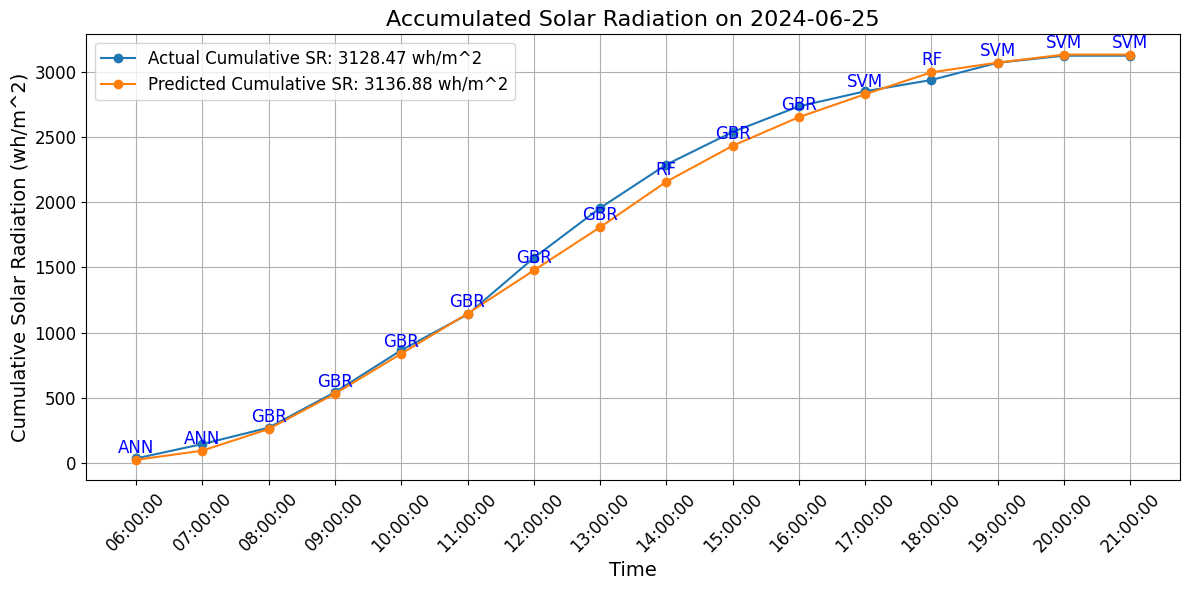

In [11]:
# Step 1: Integrate the predicted uvindex and feelslike into test_daytime_df
def integrate_predicted_uv_fl(test_daytime_df, predicted_uv_fl_df):
    # Ensure the 'Dates' and 'Time' columns are in datetime format in both DataFrames
    predicted_uv_fl_df['Datetime'] = predicted_uv_fl_df['Time']
    test_daytime_df = pd.merge(test_daytime_df, predicted_uv_fl_df[['Datetime', 'uvindex', 'feelslike']],
                               on=['Datetime'], how='left', suffixes=('', '_predicted'))

    # Use the predicted values if they are present
    test_daytime_df['uvindex'] = test_daytime_df['uvindex_predicted'].fillna(test_daytime_df['uvindex'])
    test_daytime_df['feelslike'] = test_daytime_df['feelslike_predicted'].fillna(test_daytime_df['feelslike'])

    # Drop the temporary columns
    test_daytime_df.drop(columns=['uvindex_predicted', 'feelslike_predicted'], inplace=True)

    return test_daytime_df

# Example usage of integration
test_daytime_df = integrate_predicted_uv_fl(test_daytime_df, predicted_total_uv_fl)

# Step 2: Update the classification and prediction logic
def classify_and_predict(test_daytime_df, final_models, kmeans):
    # Classify each time into a cluster and predict SR using the corresponding model
    model_names = {}  # To store model names for each time
    predictions = []  # To store predictions for each time


    # Iterate over each row in the test dataframe
    for i, row in test_daytime_df.iterrows():
        # Extract the features for clustering
        features = pd.DataFrame({'uvindex': [row['uvindex']], 'feelslike': [row['feelslike']]})
        cluster = kmeans.predict(features)[0]  # Classify into a cluster

        # Retrieve the model and scaler for the cluster
        model_info = final_models[cluster]
        model = model_info['model']
        scaler = model_info['scaler']

        # Create a DataFrame with the feature names to maintain consistency
        feature_df = pd.DataFrame({'Time_hour': [row['Time_hour']], 'uvindex': [row['uvindex']], 'feelslike': [row['feelslike']]})

        # Scale the features for prediction
        scaled_features = scaler.transform(feature_df)
        prediction = model.predict(scaled_features)[0]  # Predict the SR

        # Store the prediction and the model name
        predictions.append(prediction)
        model_names[row['Time']] = type(model).__name__

    # Add the predictions to the dataframe
    test_daytime_df['Predicted Hourly SR (wh/m^2)'] = predictions

    return test_daytime_df, model_names

# Example usage
test_daytime_df, model_names = classify_and_predict(test_daytime_df, final_models, kmeans)

def plot_accumulated_sr_comparison(test_daytime_df, date, model_names):
    # Mapping of model names to their abbreviations
    model_abbreviations = {
        'MLPRegressor': 'ANN',
        'GradientBoostingRegressor': 'GBR',
        'RandomForestRegressor': 'RF',
        'SVR': 'SVM',
        # Add other models if necessary
    }

    # Filter the test dataframe for the specified date
    date_data = test_daytime_df[test_daytime_df['Dates'] == date].copy()

    # Fill SR with 0 for hours before 6 AM and after 8 PM
    date_data['Time_hour'] = pd.to_datetime(date_data['Time']).dt.hour
    date_data.loc[(date_data['Time_hour'] < 6) | (date_data['Time_hour'] > 20), 'Hourly SR (wh/m^2)'] = 0
    date_data.loc[(date_data['Time_hour'] < 6) | (date_data['Time_hour'] > 20), 'Predicted Hourly SR (wh/m^2)'] = 0

    # Sort by time to ensure the cumulative sum is calculated correctly
    date_data = date_data.sort_values(by='Time')

    # Calculate cumulative SR for actual and predicted values
    date_data['Actual Cumulative SR'] = date_data['Hourly SR (wh/m^2)'].cumsum()
    date_data['Predicted Cumulative SR'] = date_data['Predicted Hourly SR (wh/m^2)'].cumsum()

    # Calculate summation SR
    actual_sum_sr = date_data['Hourly SR (wh/m^2)'].sum()
    predicted_sum_sr = date_data['Predicted Hourly SR (wh/m^2)'].sum()

    # Calculate absolute error and percentage error
    absolute_error = abs(predicted_sum_sr - actual_sum_sr)
    percentage_error = (absolute_error / actual_sum_sr) * 100 if actual_sum_sr != 0 else 0

    # Print errors
    print(f"Total Actual SR: {actual_sum_sr:.2f} wh/m^2")
    print(f"Total Predicted SR: {predicted_sum_sr:.2f} wh/m^2")
    print(f"Absolute Error: {absolute_error:.2f} wh/m^2")
    print(f"Percentage Error: {percentage_error:.2f}%")

    # Plot the cumulative SR comparison
    plt.figure(figsize=(12, 6))

    # Plot actual cumulative SR
    plt.plot(date_data['Time'], date_data['Actual Cumulative SR'],
             label=f'Actual Cumulative SR: {actual_sum_sr:.2f} wh/m^2',
             marker='o')

    # Plot predicted cumulative SR
    plt.plot(date_data['Time'], date_data['Predicted Cumulative SR'],
             label=f'Predicted Cumulative SR: {predicted_sum_sr:.2f} wh/m^2',
             marker='o')

    # Annotate the plot with the model abbreviations used at each time
    for i, row in date_data.iterrows():
        model_name = model_names.get(row['Time'], 'Unknown')
        abbreviation = model_abbreviations.get(model_name, model_name)  # Default to the full name if no abbreviation is found
        plt.annotate(abbreviation,
                     (row['Time'], row['Predicted Cumulative SR']),
                     textcoords="offset points", xytext=(0, 5),
                     ha='center', fontsize=12, color='blue')

    # Adding titles and labels with larger fonts
    plt.title(f'Accumulated Solar Radiation on {date}', fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Cumulative Solar Radiation (wh/m^2)', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)

    # Display the plot
    plt.tight_layout()
    plt.show()
# Example usage to plot for a specific date
plot_accumulated_sr_comparison(test_daytime_df, test_start_date, model_names)



<ipython-input-9-c8cba2b7f487>:123: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_data['Time_hour'] = pd.to_datetime(date_data['Time']).dt.hour


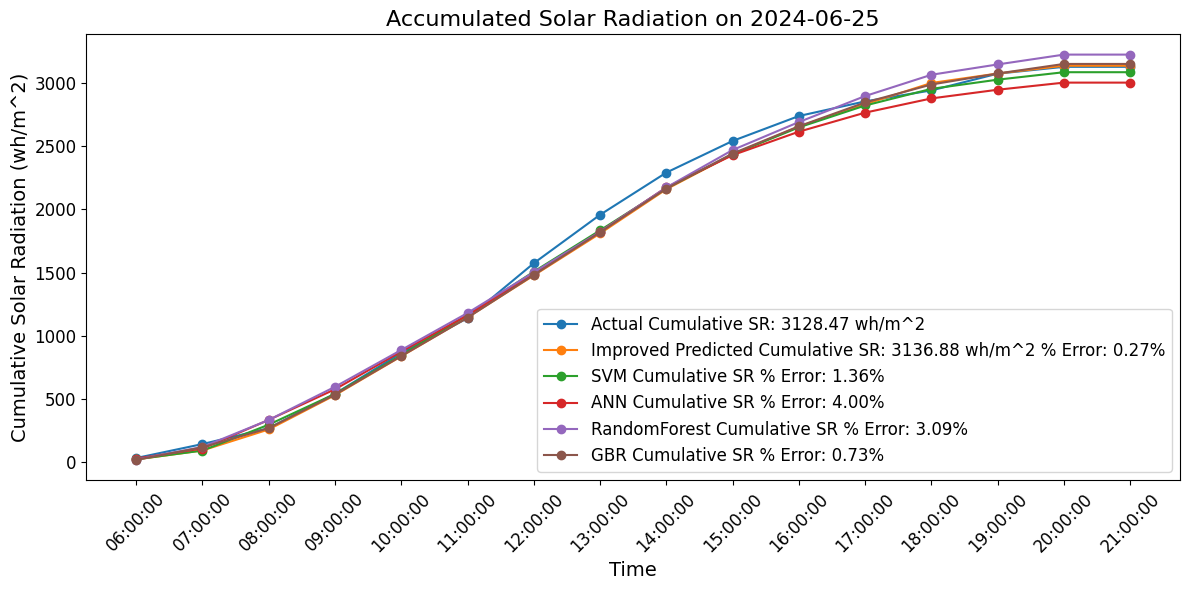

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# # Step 1: Train each model on the entire training dataset and predict SR
# def train_and_predict(models, X_train, y_train, X_test_scaled):
#     predictions = {}
#     for model_name, model in models.items():
#         # Fit the model on the training data
#         model.fit(X_train, y_train)

#         # Predict using the fitted model
#         y_pred = model.predict(X_test_scaled)
#         predictions[model_name] = y_pred
#     return predictions

# # Step 2: Prepare the training data
# X_train = combined_train_data[['Time_hour', 'uvindex', 'feelslike']]
# y_train = combined_train_data['Hourly SR (wh/m^2)']

# # Scale the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Step 3: Train models (SVM, ANN, RF, GBR) on the combined data and predict SR
# models = {
#     'SVM': SVR(kernel='rbf', C=50, gamma='scale', epsilon=0.1),
#     'ANN': MLPRegressor(hidden_layer_sizes=(100, 100), learning_rate_init=0.01, max_iter=500, random_state=42, early_stopping=True),
#     'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
#     'GBR': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
# }

# # Train models and predict SR for each model
# model_predictions = train_and_predict(models, X_train_scaled, y_train, X_test_scaled)

# # Step 4: Calculate cumulative SR for actual and each model's predictions
# def calculate_cumulative_sr(test_daytime_df, model_predictions):
#     # Copy test dataframe
#     df = test_daytime_df.copy()

#     # Calculate cumulative actual SR
#     df['Actual Cumulative SR'] = df['Hourly SR (wh/m^2)'].cumsum()

#     # Calculate cumulative predicted SR for each model
#     for model_name, y_pred in model_predictions.items():
#         df[f'{model_name} Predicted SR'] = y_pred
#         df[f'{model_name} Cumulative SR'] = df[f'{model_name} Predicted SR'].cumsum()

#     return df

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Step 1: Train each model on the entire training dataset and predict SR
def train_and_predict(models, X_train, y_train, X_test_scaled):
    predictions = {}
    for model_name, model in models.items():
        # Fit the model on the training data
        model.fit(X_train, y_train)

        # Predict using the fitted model
        y_pred = model.predict(X_test_scaled)
        predictions[model_name] = y_pred
    return predictions

# Step 2: Prepare the training data
X_train = combined_train_data[['Time_hour', 'uvindex', 'feelslike']]
y_train = combined_train_data['Hourly SR (wh/m^2)']

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Scale the test data
X_test = test_daytime_df[['Time_hour', 'uvindex', 'feelslike']]
X_test_scaled = scaler.transform(X_test)

# Step 3: Train models (SVM, ANN, RF, GBR) on the combined data and predict SR
models = {
    'SVM': SVR(kernel='rbf', C=50, gamma='scale', epsilon=0.1),
    'ANN': MLPRegressor(hidden_layer_sizes=(100, 100), learning_rate_init=0.01, max_iter=500, random_state=42, early_stopping=True),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    'GBR': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# Train models and predict SR for each model
model_predictions = train_and_predict(models, X_train_scaled, y_train, X_test_scaled)

# Step 4: Calculate cumulative SR for actual and each model's predictions
def calculate_cumulative_sr(test_daytime_df, model_predictions):
    # Copy test dataframe
    df = test_daytime_df.copy()

    # Ensure predictions match the test data length
    for model_name, y_pred in model_predictions.items():
        if len(y_pred) != len(df):
            raise ValueError(f"Length of predictions ({len(y_pred)}) for model '{model_name}' does not match length of test data ({len(df)})")

    # Calculate cumulative actual SR
    df['Actual Cumulative SR'] = df['Hourly SR (wh/m^2)'].cumsum()

    # Calculate cumulative predicted SR for each model
    for model_name, y_pred in model_predictions.items():
        df[f'{model_name} Predicted SR'] = y_pred
        df[f'{model_name} Cumulative SR'] = df[f'{model_name} Predicted SR'].cumsum()

    return df

# # Apply the cumulative calculation function
# test_daytime_df = calculate_cumulative_sr(test_daytime_df, model_predictions)


# Apply the cumulative calculation function
test_daytime_df = calculate_cumulative_sr(test_daytime_df, model_predictions)

def plot_combined_comparison(test_daytime_df, date, model_names):
    # Filter the test dataframe for the specified date
    date_data = test_daytime_df[test_daytime_df['Dates'] == date].copy()

    # Fill SR with 0 for hours before 6 AM and after 8 PM
    date_data['Time_hour'] = pd.to_datetime(date_data['Time']).dt.hour
    date_data.loc[(date_data['Time_hour'] < 6) | (date_data['Time_hour'] > 20), 'Hourly SR (wh/m^2)'] = 0
    date_data.loc[(date_data['Time_hour'] < 6) | (date_data['Time_hour'] > 20), 'Predicted Hourly SR (wh/m^2)'] = 0
    for model_name in model_predictions.keys():
        date_data.loc[(date_data['Time_hour'] < 6) | (date_data['Time_hour'] > 20), f'{model_name} Predicted SR'] = 0

    # Sort by time to ensure the cumulative sum is calculated correctly
    date_data = date_data.sort_values(by='Time')

    # Calculate cumulative SR for actual, improved, and each model's predictions
    date_data['Actual Cumulative SR'] = date_data['Hourly SR (wh/m^2)'].cumsum()
    date_data['Predicted Cumulative SR'] = date_data['Predicted Hourly SR (wh/m^2)'].cumsum()
    model_errors = {}
    for model_name in model_predictions.keys():
        date_data[f'{model_name} Cumulative SR'] = date_data[f'{model_name} Predicted SR'].cumsum()
        # Calculate absolute and percentage error for each model
        predicted_sum_sr_model = date_data[f'{model_name} Predicted SR'].sum()
        absolute_error_model = abs(predicted_sum_sr_model - date_data['Hourly SR (wh/m^2)'].sum())
        percentage_error_model = (absolute_error_model / date_data['Hourly SR (wh/m^2)'].sum()) * 100 if date_data['Hourly SR (wh/m^2)'].sum() != 0 else 0
        model_errors[model_name] = percentage_error_model

    # Calculate summation SR for the improved model
    actual_sum_sr = date_data['Hourly SR (wh/m^2)'].sum()
    predicted_sum_sr = date_data['Predicted Hourly SR (wh/m^2)'].sum()

    # Calculate absolute error and percentage error for the improved model
    absolute_error = abs(predicted_sum_sr - actual_sum_sr)
    percentage_error = (absolute_error / actual_sum_sr) * 100 if actual_sum_sr != 0 else 0

    # Plot the cumulative SR comparison
    plt.figure(figsize=(12, 6))

    # Plot actual cumulative SR
    plt.plot(date_data['Time'], date_data['Actual Cumulative SR'], label=f'Actual Cumulative SR: {actual_sum_sr:.2f} wh/m^2', marker='o')

    # Plot cumulative SR for the improved model
    plt.plot(date_data['Time'], date_data['Predicted Cumulative SR'], label=f'Improved Predicted Cumulative SR: {predicted_sum_sr:.2f} wh/m^2 % Error: {percentage_error:.2f}%', marker='o')

    # Plot cumulative SR for each model
    for model_name in model_predictions.keys():
        plt.plot(date_data['Time'], date_data[f'{model_name} Cumulative SR'], label=f'{model_name} Cumulative SR % Error: {model_errors[model_name]:.2f}%', marker='o')

    # Adding titles and labels with larger fonts
    plt.title(f'Accumulated Solar Radiation on {date}', fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Cumulative Solar Radiation (wh/m^2)', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example usage
plot_combined_comparison(test_daytime_df, test_start_date, model_names)


## Method 2: Train the accumulation SR

In [ ]:
import pandas as pd

# Ensure 'Dates' is in datetime format
raw_total_df['Dates'] = pd.to_datetime(raw_total_df['Dates'])

# Sort the DataFrame by 'Dates' and 'Time' to ensure proper accumulation
raw_total_df = raw_total_df.sort_values(by=['Dates', 'Time_hour'])

# Create the accumulative SR column by grouping by 'Dates' and taking the cumulative sum
raw_total_df['Accumulative SR (wh/m^2)'] = raw_total_df.groupby('Dates')['Hourly SR (wh/m^2)'].cumsum()


In [ ]:
raw_total_df

,Datetime,Hourly SR (wh/m^2),Day/Night,Dates,Time,temp,feelslike,dew,humidity,precip,...,solarradiation,solarenergy,uvindex,severerisk,conditions,pressure,icon,Sun Elevation,Time_hour,Accumulative SR (wh/m^2)
0,2024-05-21 00:00:00,0.000,Nighttime,2024-05-21,00:00:00,12.7,12.7,8.2,74.31,0.000,...,0.0,0.0,0.0,10.0,Partially cloudy,1016.3,NaN,36.703945,0.0,0.000
1,2024-05-21 01:00:00,0.000,Nighttime,2024-05-21,01:00:00,12.5,12.5,7.2,70.00,0.236,...,0.0,0.0,0.0,10.0,"Rain, Partially cloudy",1016.3,NaN,26.981862,1.0,0.000
2,2024-05-21 02:00:00,0.000,Nighttime,2024-05-21,02:00:00,12.1,12.1,7.2,71.55,0.000,...,0.0,0.0,0.0,10.0,Overcast,1016.3,NaN,17.263847,2.0,0.000
3,2024-05-21 03:00:00,0.000,Nighttime,2024-05-21,03:00:00,11.5,11.5,8.0,78.99,0.236,...,0.0,0.0,0.0,10.0,"Rain, Partially cloudy",1016.3,NaN,7.907092,3.0,0.000
4,2024-05-21 04:00:00,0.000,Nighttime,2024-05-21,04:00:00,11.1,11.1,8.2,82.25,0.079,...,0.0,0.0,0.0,10.0,"Rain, Overcast",1016.3,NaN,-0.748172,4.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1862,2024-08-12 11:00:00,225.655,Daytime,2024-08-12,11:00:00,17.0,17.0,13.3,78.52,0.000,...,241.0,0.9,2.0,10.0,Partially cloudy,1016.3,NaN,-16.350805,11.0,672.095
1863,2024-08-12 12:00:00,226.480,Daytime,2024-08-12,12:00:00,17.0,17.0,12.8,76.73,0.000,...,275.0,1.0,3.0,10.0,Partially cloudy,1016.3,NaN,-8.994347,12.0,898.575
1864,2024-08-12 13:00:00,253.795,Daytime,2024-08-12,13:00:00,17.5,17.5,13.1,75.09,0.000,...,325.0,1.2,3.0,10.0,Partially cloudy,1016.3,NaN,-0.437289,13.0,1152.370
1865,2024-08-12 14:00:00,244.595,Daytime,2024-08-12,14:00:00,18.1,18.1,12.7,70.86,0.000,...,289.0,1.0,3.0,10.0,Partially cloudy,1016.3,NaN,8.885665,14.0,1396.965


### **ANN**

/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_5873/2963194921.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred


Test dates: 2024-05-25 to 2024-05-30
ANN - Method 2
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Absolute Error  \
Dates                                                                     
2024-05-25             1576.750             1653.657968       76.907968   
2024-05-26              900.660             1103.221044      202.561044   
2024-05-27             1072.645             1680.904573      608.259573   
2024-05-28             1141.405             1599.164759      457.759759   
2024-05-29             1992.805             1626.411363      366.393637   
2024-05-30             2313.530             1926.124015      387.405985   

            Percentage Error (%)  
Dates                             
2024-05-25              4.877626  
2024-05-26             22.490290  
2024-05-27             56.706513  
2024-05-28             40.104937  
2024-05-29             18.385825  
2024-05-30             16.745233  
Average Daily Absolute Error:

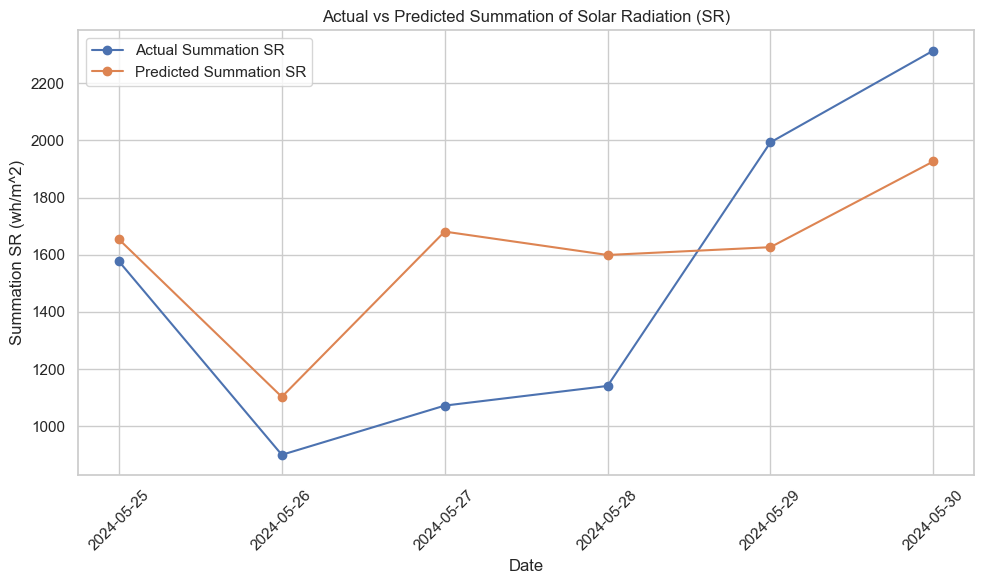

In [ ]:
# Define the test period
test_start_date = '2024-05-25'
test_end_date = '2024-05-30'

# Filter the data for daytime only
daytime_df = raw_total_df[raw_total_df['Day/Night'] == 'Daytime']

# Drop the 'Day/Night' column since it's no longer needed
daytime_df = daytime_df.drop(columns=['Day/Night'])

# Split the data into training and testing sets
train_df = daytime_df[(daytime_df['Dates'] < test_start_date) | (daytime_df['Dates'] > test_end_date)]
test_df = daytime_df[(daytime_df['Dates'] >= test_start_date) & (daytime_df['Dates'] <= test_end_date)]

# Define features and target
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Accumulative SR (wh/m^2)'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Train the ANN model
ann = MLPRegressor(hidden_layer_sizes=(100, 100), learning_rate_init=0.01, max_iter=500, random_state=42)
ann.fit(X_train_scaled, y_train)

# Predict the cumulative SR for the test set
y_pred = ann.predict(X_test_scaled)

# Add predictions to the test dataframe
test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for each day in the test set
actual_summation_sr = test_df.groupby('Dates')['Accumulative SR (wh/m^2)'].last()
predicted_summation_sr = test_df.groupby('Dates')['Predicted Accumulative SR (wh/m^2)'].last()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

# Calculate daily errors
comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100

# Drop the 'Daily Error' column from the display
comparison_df.drop(columns=['Daily Error'], inplace=True)

# Display the comparison dataframe
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('ANN - Method 2')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: ' + str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


### **Polynomial Regression**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_5873/3085961295.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred


Test dates: 2024-05-20 to 2024-05-25
Polynomial Regression - Method 2
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Absolute Error  \
Dates                                                                     
2024-05-21              783.350              903.844953      120.494953   
2024-05-22             1868.995             1961.971434       92.976434   
2024-05-23             2349.935             1846.996013      502.938987   
2024-05-24             1040.880              732.784291      308.095709   
2024-05-25             1576.750             1639.686746       62.936746   

            Percentage Error (%)  
Dates                             
2024-05-21             15.382007  
2024-05-22              4.974675  
2024-05-23             21.402251  
2024-05-24             29.599542  
2024-05-25              3.991549  
Average Daily Absolute Error: 217.48856589955872


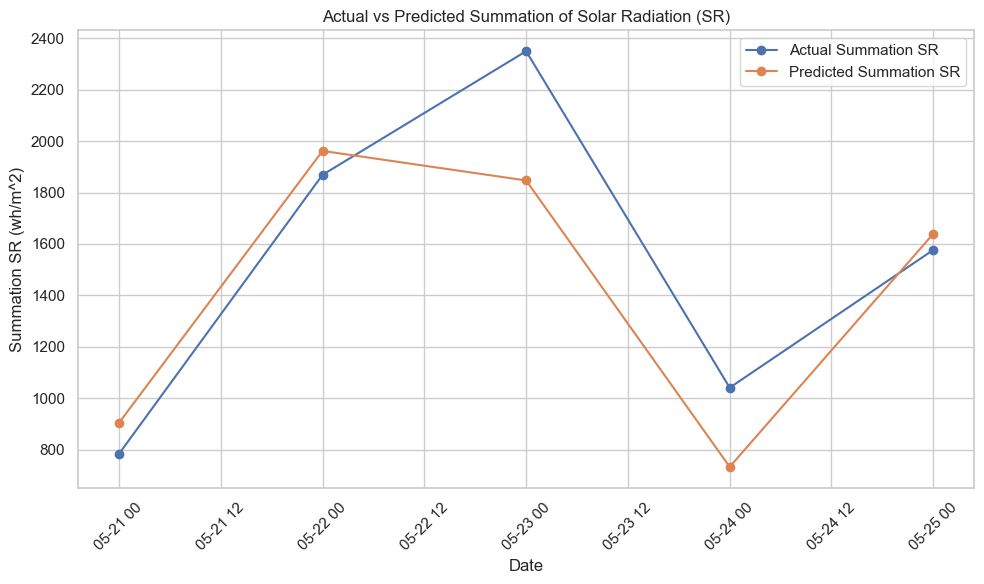

In [ ]:
# Define the test period
test_start_date = '2024-05-20'
test_end_date = '2024-05-25'

# Filter the data for daytime only
daytime_df = raw_total_df[raw_total_df['Day/Night'] == 'Daytime']

# Drop the 'Day/Night' column since it's no longer needed
daytime_df = daytime_df.drop(columns=['Day/Night'])

# Split the data into training and testing sets
train_df = daytime_df[(daytime_df['Dates'] < test_start_date) | (daytime_df['Dates'] > test_end_date)]
test_df = daytime_df[(daytime_df['Dates'] >= test_start_date) & (daytime_df['Dates'] <= test_end_date)]

# Define features and target
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Accumulative SR (wh/m^2)'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the polynomial regression model
degree = 2  # Adjust the degree of the polynomial as needed
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Train the polynomial regression model
poly_model.fit(X_train_scaled, y_train)

# Predict the cumulative SR for the test set
y_pred = poly_model.predict(X_test_scaled)

# Add predictions to the test dataframe
test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for each day in the test set
actual_summation_sr = test_df.groupby('Dates')['Accumulative SR (wh/m^2)'].last()
predicted_summation_sr = test_df.groupby('Dates')['Predicted Accumulative SR (wh/m^2)'].last()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

# Calculate daily errors
comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100

# Drop the 'Daily Error' column from the display
comparison_df.drop(columns=['Daily Error'], inplace=True)

# Display the comparison dataframe
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('Polynomial Regression - Method 2')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: ' + str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


### **Random Forest**


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_5873/3961849458.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred


Test dates: 2024-05-20 to 2024-05-25
Random Forest - Method 2
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Absolute Error  \
Dates                                                                     
2024-05-21              783.350             1051.447324      268.097324   
2024-05-22             1868.995             2154.556197      285.561197   
2024-05-23             2349.935             1686.083394      663.851606   
2024-05-24             1040.880             1049.938799        9.058799   
2024-05-25             1576.750             1544.815038       31.934962   

            Percentage Error (%)  
Dates                             
2024-05-21             34.224462  
2024-05-22             15.278864  
2024-05-23             28.249786  
2024-05-24              0.870302  
2024-05-25              2.025366  
Average Daily Absolute Error: 251.70077775209216


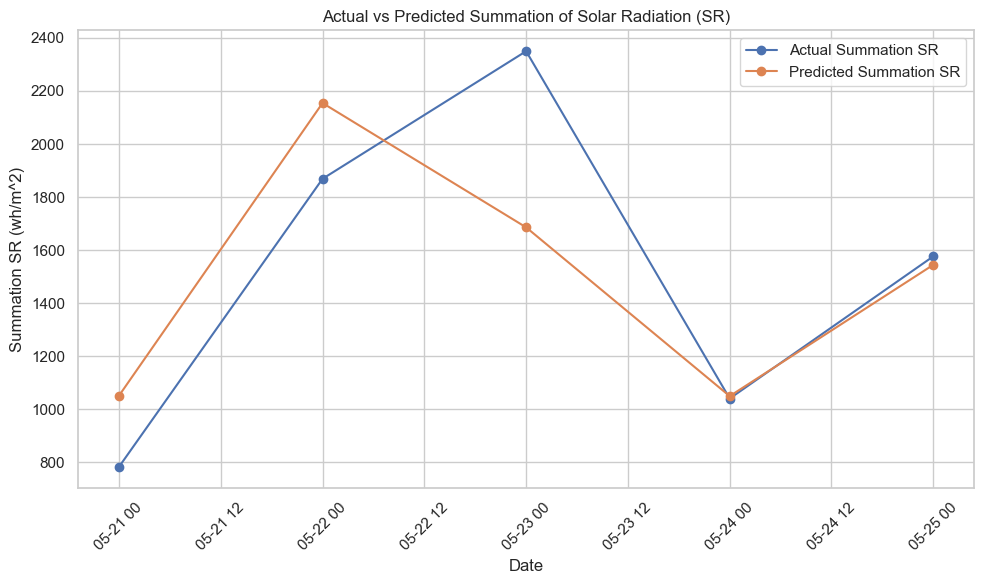

In [ ]:
# Define the test period
test_start_date = '2024-05-20'
test_end_date = '2024-05-25'

# Filter the data for daytime only
daytime_df = raw_total_df[raw_total_df['Day/Night'] == 'Daytime']

# Drop the 'Day/Night' column since it's no longer needed
daytime_df = daytime_df.drop(columns=['Day/Night'])

# Split the data into training and testing sets
train_df = daytime_df[(daytime_df['Dates'] < test_start_date) | (daytime_df['Dates'] > test_end_date)]
test_df = daytime_df[(daytime_df['Dates'] >= test_start_date) & (daytime_df['Dates'] <= test_end_date)]

# Define features and target
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Accumulative SR (wh/m^2)'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Random Forest model
rf_model = RandomForestRegressor(n_estimators = 400, max_depth=5, random_state=42)

# Train the Random Forest model
rf_model.fit(X_train_scaled, y_train)

# Predict the cumulative SR for the test set
y_pred = rf_model.predict(X_test_scaled)

# Add predictions to the test dataframe
test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for each day in the test set
actual_summation_sr = test_df.groupby('Dates')['Accumulative SR (wh/m^2)'].last()
predicted_summation_sr = test_df.groupby('Dates')['Predicted Accumulative SR (wh/m^2)'].last()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

# Calculate daily errors
comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100

# Drop the 'Daily Error' column from the display
comparison_df.drop(columns=['Daily Error'], inplace=True)

# Display the comparison dataframe
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('Random Forest - Method 2')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: ' + str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


### **SVM**

/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_5873/1349485433.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred


Test dates: 2024-05-20 to 2024-05-25
SVM - Method 2
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Absolute Error  \
Dates                                                                     
2024-05-21              783.350             1096.217421      312.867421   
2024-05-22             1868.995             1892.985176       23.990176   
2024-05-23             2349.935             1785.022601      564.912399   
2024-05-24             1040.880             1016.011671       24.868329   
2024-05-25             1576.750             1601.039024       24.289024   

            Percentage Error (%)  
Dates                             
2024-05-21             39.939672  
2024-05-22              1.283587  
2024-05-23             24.039490  
2024-05-24              2.389164  
2024-05-25              1.540449  
Average Daily Absolute Error: 190.18546989239127


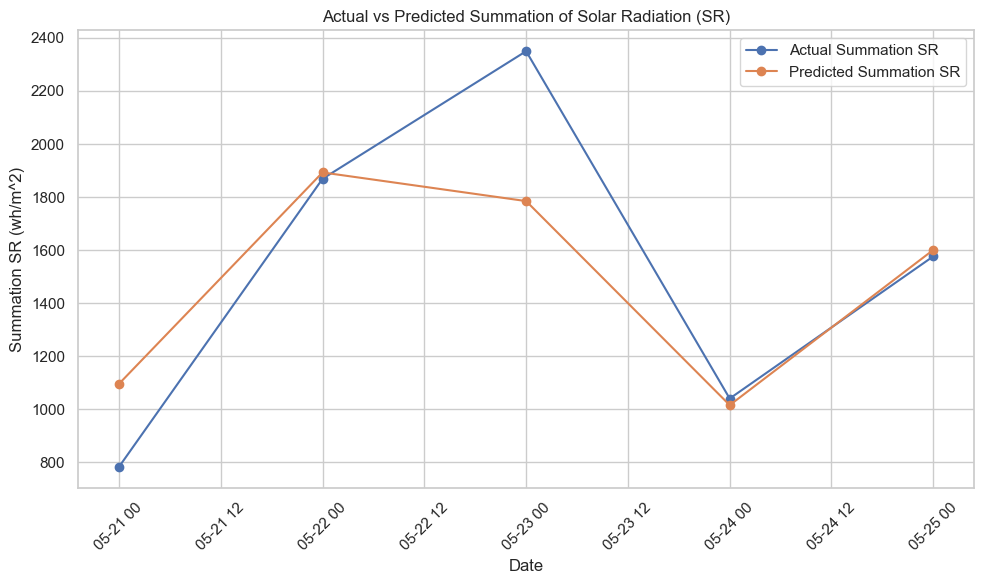

In [ ]:
# Define the test period
test_start_date = '2024-05-20'
test_end_date = '2024-05-25'

# Filter the data for daytime only
daytime_df = raw_total_df[raw_total_df['Day/Night'] == 'Daytime']

# Drop the 'Day/Night' column since it's no longer needed
daytime_df = daytime_df.drop(columns=['Day/Night'])

# Split the data into training and testing sets
train_df = daytime_df[(daytime_df['Dates'] < test_start_date) | (daytime_df['Dates'] > test_end_date)]
test_df = daytime_df[(daytime_df['Dates'] >= test_start_date) & (daytime_df['Dates'] <= test_end_date)]

# Define features and target
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Accumulative SR (wh/m^2)'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the SVM model
svm_model = SVR(kernel='rbf', C=200, gamma='scale', epsilon=0.1)

# Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# Predict the cumulative SR for the test set
y_pred = svm_model.predict(X_test_scaled)

# Add predictions to the test dataframe
test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for each day in the test set
actual_summation_sr = test_df.groupby('Dates')['Accumulative SR (wh/m^2)'].last()
predicted_summation_sr = test_df.groupby('Dates')['Predicted Accumulative SR (wh/m^2)'].last()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

# Calculate daily errors
comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100

# Drop the 'Daily Error' column from the display
comparison_df.drop(columns=['Daily Error'], inplace=True)

# Display the comparison dataframe
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('SVM - Method 2')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: ' + str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


### **Decision Tree**

/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_5873/1552040476.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred


Test dates: 2024-05-20 to 2024-05-25
Decision Tree - Method 2
['Time_hour', 'uvindex', 'feelslike']
            Actual Summation SR  Predicted Summation SR  Absolute Error  \
Dates                                                                     
2024-05-21              783.350              900.660000      117.310000   
2024-05-22             1868.995             2273.871429      404.876429   
2024-05-23             2349.935             1070.347500     1279.587500   
2024-05-24             1040.880              900.660000      140.220000   
2024-05-25             1576.750             1488.081667       88.668333   

            Percentage Error (%)  
Dates                             
2024-05-21             14.975426  
2024-05-22             21.662788  
2024-05-23             54.452038  
2024-05-24             13.471294  
2024-05-25              5.623487  
Average Daily Absolute Error: 406.1324523809524


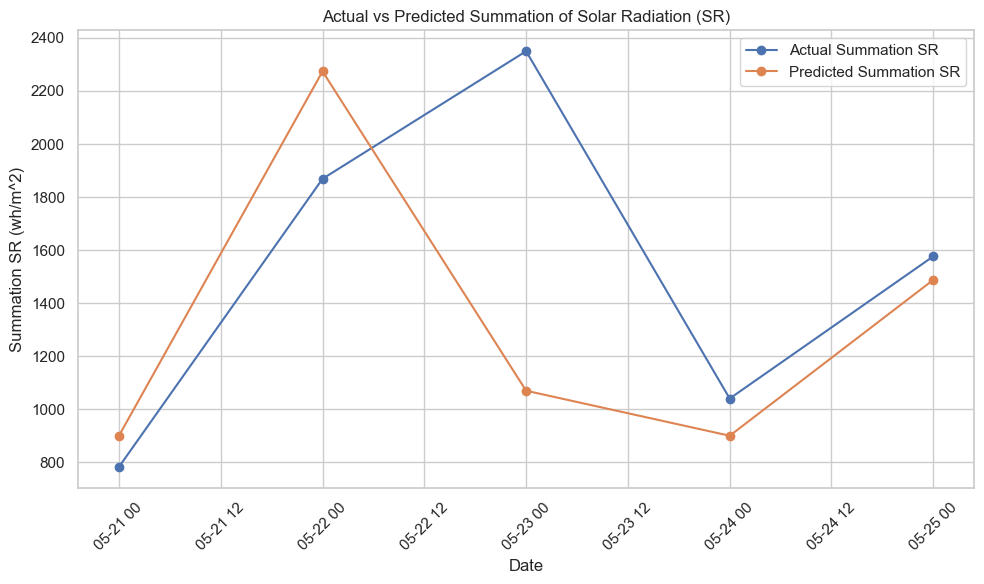

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Define the test period
test_start_date = '2024-05-20'
test_end_date = '2024-05-25'

# Filter the data for daytime only
daytime_df = raw_total_df[raw_total_df['Day/Night'] == 'Daytime']

# Drop the 'Day/Night' column since it's no longer needed
daytime_df = daytime_df.drop(columns=['Day/Night'])

# Split the data into training and testing sets
train_df = daytime_df[(daytime_df['Dates'] < test_start_date) | (daytime_df['Dates'] > test_end_date)]
test_df = daytime_df[(daytime_df['Dates'] >= test_start_date) & (daytime_df['Dates'] <= test_end_date)]

# Define features and target
features = ['Time_hour', 'uvindex', 'feelslike']
target = 'Accumulative SR (wh/m^2)'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Decision Tree model
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train_scaled, y_train)

# Predict the cumulative SR for the test set
y_pred = dt_model.predict(X_test_scaled)

# Add predictions to the test dataframe
test_df['Predicted Accumulative SR (wh/m^2)'] = y_pred

# Calculate the actual and predicted summation of SR for each day in the test set
actual_summation_sr = test_df.groupby('Dates')['Accumulative SR (wh/m^2)'].last()
predicted_summation_sr = test_df.groupby('Dates')['Predicted Accumulative SR (wh/m^2)'].last()

# Combine the results into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Summation SR': actual_summation_sr,
    'Predicted Summation SR': predicted_summation_sr
})

# Calculate daily errors
comparison_df['Daily Error'] = comparison_df['Predicted Summation SR'] - comparison_df['Actual Summation SR']
comparison_df['Absolute Error'] = abs(comparison_df['Daily Error'])
comparison_df['Percentage Error (%)'] = (comparison_df['Absolute Error'] / comparison_df['Actual Summation SR']) * 100

# Drop the 'Daily Error' column from the display
comparison_df.drop(columns=['Daily Error'], inplace=True)

# Display the comparison dataframe
print('Test dates: ' + test_start_date + ' to ' + test_end_date)
print('Decision Tree - Method 2')
print(str(features))
print(comparison_df)
print('Average Daily Absolute Error: ' + str(comparison_df['Absolute Error'].mean()))

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot actual summation SR
plt.plot(comparison_df.index, comparison_df['Actual Summation SR'], label='Actual Summation SR', marker='o')

# Plot predicted summation SR
plt.plot(comparison_df.index, comparison_df['Predicted Summation SR'], label='Predicted Summation SR', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Summation of Solar Radiation (SR)')
plt.xlabel('Date')
plt.ylabel('Summation SR (wh/m^2)')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()
